Analysis of 2026-05-06 RFI monitor Data

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
from astropy.convolution import Gaussian1DKernel, convolve
import scipy.stats as stats


def k(x):
    return x*1000

def M(x):
    return x*1e6

def G(x):
    return x*1e9

data_file = '../../rfi_data/RFInd-calibrated-2026-05-06T01.sigmf-data'
f_max = 2000 # MHz
f_min = 0 # MHz
chord_min = 300
chord_max = 1500


## Get line locations

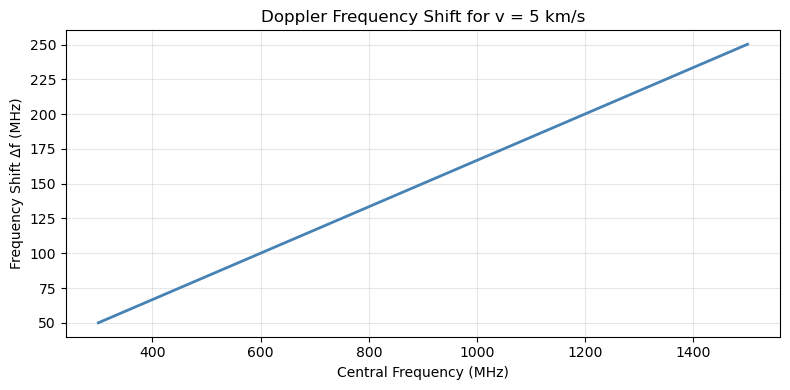

In [3]:
def freq_change_for_velocity(central_freq_mhz, velocity_kms=5.0, c_kms=299792.458):
    """
    Frequency shift (kHz) corresponding to a radial velocity at a given central frequency.

    Uses the non-relativistic Doppler approximation:
        Δf / f = v / c
    """
    return central_freq_mhz * (velocity_kms / c_kms) * 1e3

freq_mhz = np.linspace(300, 1500, 1000)
delta_f_mhz = freq_change_for_velocity(freq_mhz, velocity_kms=50)

plt.figure(figsize=(8, 4))
plt.plot(freq_mhz, delta_f_mhz, color="steelblue", lw=2)
plt.xlabel("Central Frequency (MHz)")
plt.ylabel("Frequency Shift Δf (MHz)")
plt.title("Doppler Frequency Shift for v = 5 km/s")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
transitions_df = pd.read_csv("../../rfi_data/transitions_parsed.zip")

R_H_c = 3.288051e15  # Hz, Rydberg frequency for hydrogen (reduced-mass corrected)

def H_alpha(n):
    """Frequency (MHz) of the Hnα recombination line, transition (n+1) -> n."""
    return R_H_c * (1/n**2 - 1/(n + 1)**2) / 1e6

H_lines = transitions_df[
    (transitions_df.Species == "H") & transitions_df["Frequency (MHz)"].between(chord_min, chord_max)
    ].sort_values("Frequency (MHz)", ascending=False).reset_index(drop=True)
for n in range(254, 280):
    H_lines.loc[len(H_lines)] = [f"H{n}alpha", "H", f"H{n}", H_alpha(n)]

H_lines

,Transition,Species,Line,Frequency (MHz)
0,H164alpha,H,H164,1477.335105
1,H165alpha,H,H165,1450.716777
2,H166alpha,H,H166,1424.734102
3,H167alpha,H,H167,1399.368217
4,H168alpha,H,H168,1374.600927
...,...,...,...,...
111,H275alpha,H,H275,314.489820
112,H276alpha,H,H276,311.089945
113,H277alpha,H,H277,307.738901
114,H278alpha,H,H278,304.435814


## Power by integration cycle

Data shape: (4800, 600000)


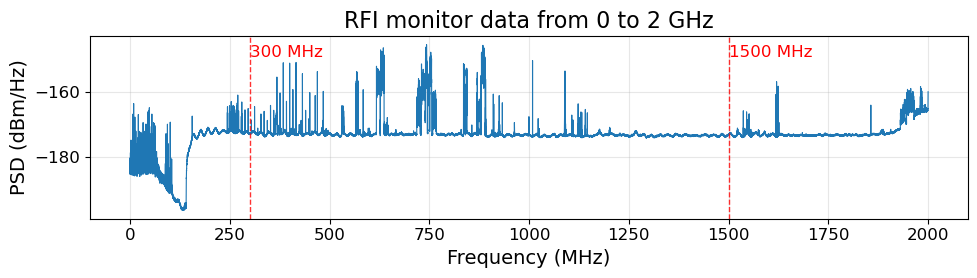

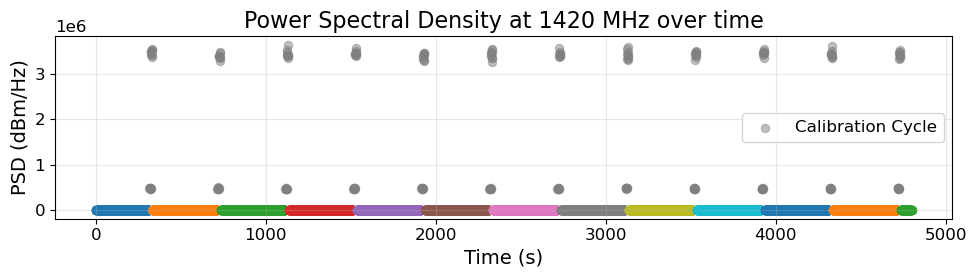

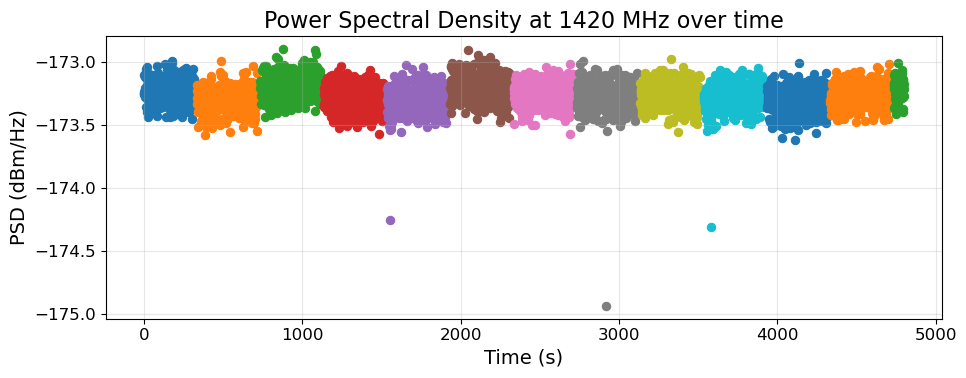

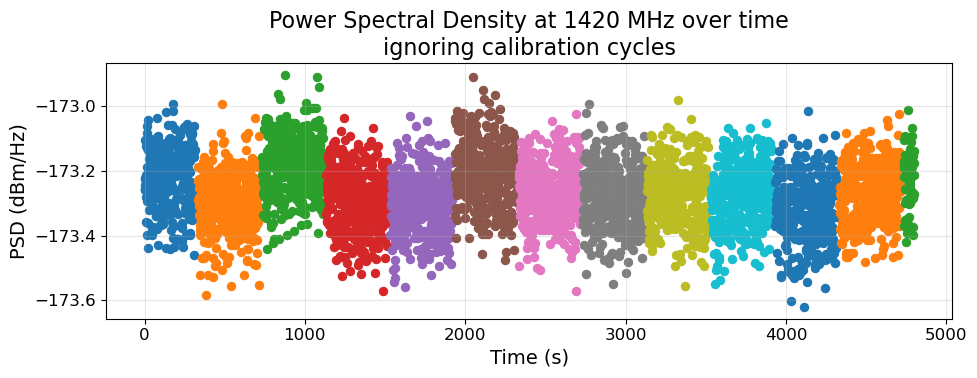

In [5]:
def load_data(file):
    data = np.memmap(file, dtype='f4', mode='r')
    data = data.reshape(-1, 600000)
    return data

data = load_data(data_file)
chord_range = np.zeros(data.shape[1], dtype=bool)
chord_range[int(chord_min/f_max*data.shape[1]):int(chord_max/f_max*data.shape[1])] = True
print(f"Data shape: {data.shape}")

f_slice = data[100, ::10]
time_slice = data[:, int(1420/2000*data.shape[1])]

freq_axis = np.linspace(0, 2000, f_slice.shape[0])
time_axis = np.arange(time_slice.shape[0])

diffs = np.diff(data[:, 100])
starts = np.where(diffs < -1e5)[0] + 1
ends = np.where(diffs > 1e5)[0] + 1
starts = np.insert(starts, 0, 0)
ends = np.append(ends, len(time_slice))

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})
plt.figure(figsize=(10, 3))
plt.plot(freq_axis, f_slice, lw=0.8)
plt.axvline(x=300, color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.text(300, max(f_slice), '300 MHz', color='red', fontsize=12, va='top', ha='left')
plt.axvline(x=1500, color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.text(1500, max(f_slice), '1500 MHz', color='red', fontsize=12, va='top', ha='left')
plt.xlabel("Frequency (MHz)")
plt.ylabel("PSD (dBm/Hz)")
plt.title("RFI monitor data from 0 to 2 GHz")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/rfi_monitor_full_slice.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 3))
plt.scatter(time_axis, time_slice, lw=0.8, color='grey', alpha=0.5, label='Calibration Cycle')
for start, end in zip(starts, ends):
    plt.scatter(time_axis[start:end], time_slice[start:end], lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel("PSD (dBm/Hz)")
plt.title("Power Spectral Density at 1420 MHz over time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for start, end in zip(starts, ends):
    plt.scatter(time_axis[start:end], time_slice[start:end], lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel("PSD (dBm/Hz)")
plt.title("Power Spectral Density at 1420 MHz over time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# memmap is read-only; make a writable copy before assigning NaN
time_slice = np.array(time_slice, copy=True)
time_slice[time_slice < -174] = np.nan
plt.figure(figsize=(10, 4))
for start, end in zip(starts, ends):
    plt.scatter(time_axis[start:end], time_slice[start:end], lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel("PSD (dBm/Hz)")
plt.title("Power Spectral Density at 1420 MHz over time\nignoring calibration cycles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



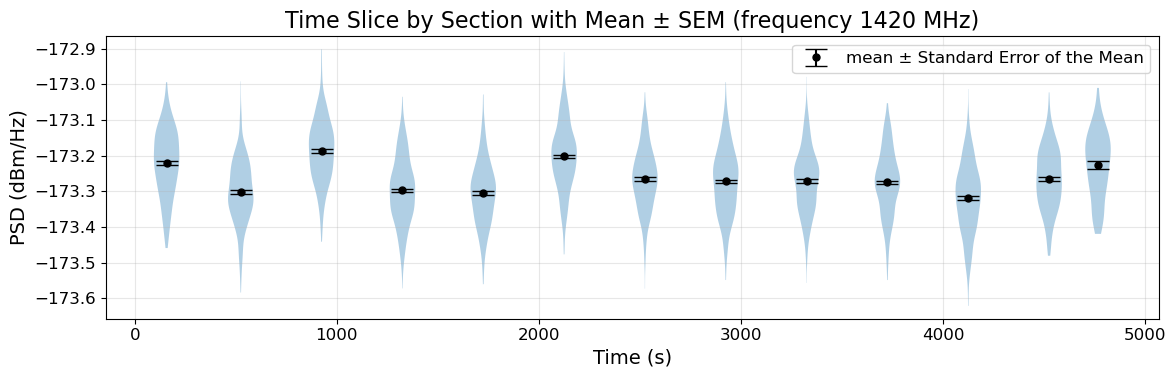

t≈  157.5s  n=  316  mean=-173.221  SEM=0.0053 dBm/Hz
t≈  524.5s  n=  382  mean=-173.301  SEM=0.0046 dBm/Hz
t≈  924.5s  n=  382  mean=-173.186  SEM=0.0046 dBm/Hz
t≈ 1324.5s  n=  382  mean=-173.297  SEM=0.0048 dBm/Hz
t≈ 1724.5s  n=  381  mean=-173.304  SEM=0.0046 dBm/Hz
t≈ 2124.5s  n=  382  mean=-173.202  SEM=0.0048 dBm/Hz
t≈ 2524.5s  n=  382  mean=-173.265  SEM=0.0045 dBm/Hz
t≈ 2924.5s  n=  381  mean=-173.272  SEM=0.0049 dBm/Hz
t≈ 3324.5s  n=  382  mean=-173.271  SEM=0.0046 dBm/Hz
t≈ 3724.5s  n=  381  mean=-173.275  SEM=0.0047 dBm/Hz
t≈ 4124.5s  n=  382  mean=-173.318  SEM=0.0050 dBm/Hz
t≈ 4524.5s  n=  382  mean=-173.265  SEM=0.0045 dBm/Hz
t≈ 4766.5s  n=   66  mean=-173.227  SEM=0.0114 dBm/Hz


In [6]:
# Violin plot of each contiguous section of the time slice, with mean +/- SEM.
# The standard error (std / sqrt(n)) shrinks with sample size, so non-overlapping
# error bars are strong evidence the section means are genuinely different.
sections = []
positions = []
means = []
sems = []
for start, end in zip(starts, ends):
    vals = time_slice[start:end]
    vals = vals[np.isfinite(vals)]   # violinplot/stats can't handle NaNs
    if vals.size == 0:
        continue
    sections.append(vals)
    positions.append(np.median(time_axis[start:end]))  # center on section's time
    means.append(vals.mean())
    sems.append(vals.std(ddof=1) / np.sqrt(vals.size))

positions = np.array(positions)
means = np.array(means)
sems = np.array(sems)

fig, ax = plt.subplots(figsize=(12, 4))
width = np.diff(np.r_[0, positions]).min() * 0.8
parts = ax.violinplot(sections, positions=positions, widths=width,
                      showmeans=False, showextrema=False)
for pc in parts["bodies"]:
    pc.set_alpha(0.35)

# Mean +/- standard error of the mean (bars enlarged for visibility)
ax.errorbar(positions, means, yerr=sems, fmt="o", color="black",
            capsize=8, lw=1.5, ms=5, label="mean ± Standard Error of the Mean")

ax.set_xlabel("Time (s)")
ax.set_ylabel("PSD (dBm/Hz)")
ax.set_title("Time Slice by Section with Mean ± SEM (frequency 1420 MHz)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Report each section's mean and SEM
for p, m, s, vals in zip(positions, means, sems, sections):
    print(f"t≈{p:7.1f}s  n={vals.size:5d}  mean={m:8.3f}  SEM={s:.4f} dBm/Hz")

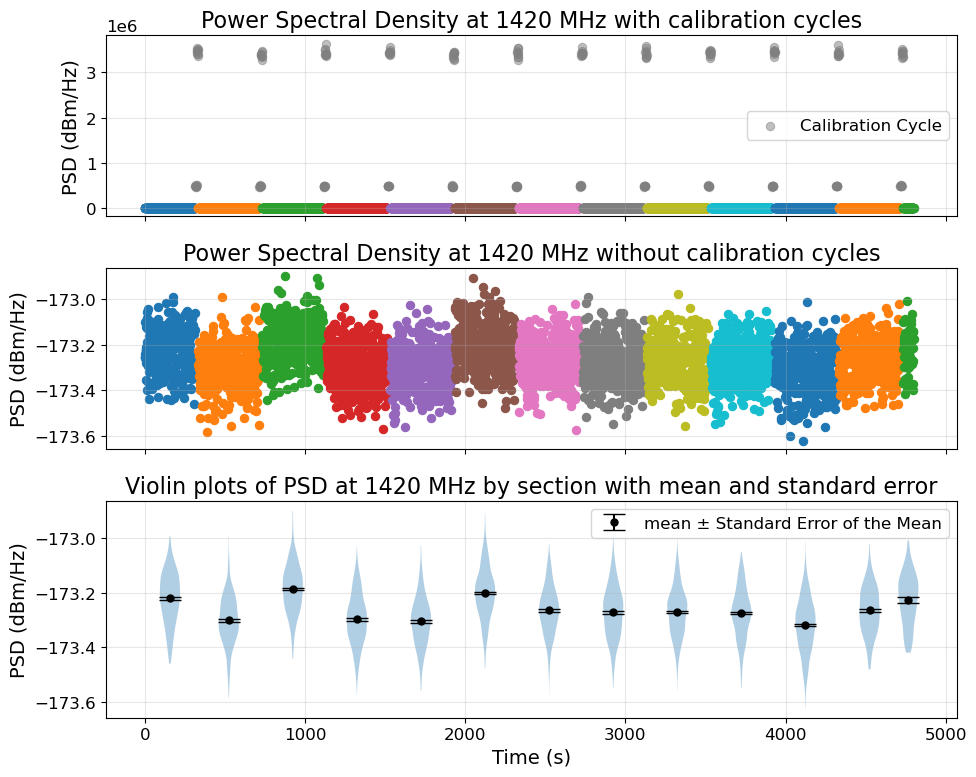

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1.2]}
)

# --- 1) With calibration cycles ---
ax1.scatter(time_axis, time_slice, lw=0.8, color="grey", alpha=0.5, label="Calibration Cycle")
for start, end in zip(starts, ends):
    ax1.scatter(time_axis[start:end], time_slice[start:end], lw=0.8)
ax1.set_ylabel("PSD (dBm/Hz)")
ax1.set_title("Power Spectral Density at 1420 MHz with calibration cycles")
ax1.grid(alpha=0.3)
ax1.legend()

# --- 2) Without calibration cycles ---
time_slice_no_cal = np.array(time_slice, copy=True)
time_slice_no_cal[time_slice_no_cal < -174] = np.nan
for start, end in zip(starts, ends):
    ax2.scatter(time_axis[start:end], time_slice_no_cal[start:end], lw=0.8)
ax2.set_ylabel("PSD (dBm/Hz)")
ax2.set_title("Power Spectral Density at 1420 MHz without calibration cycles")
ax2.grid(alpha=0.3)

# --- 3) Violin + mean ± SEM ---
width = np.diff(np.r_[0, positions]).min() * 0.8
parts = ax3.violinplot(
    sections, positions=positions, widths=width,
    showmeans=False, showextrema=False
)

# Pyright-safe handling: "bodies" may be typed as a single Collection
bodies = parts["bodies"]
if not isinstance(bodies, (list, tuple)):
    bodies = [bodies]
for pc in bodies:
    pc.set_alpha(0.35)

ax3.errorbar(
    positions, means, yerr=sems, fmt="o", color="black",
    capsize=8, lw=1.5, ms=5, label="mean ± Standard Error of the Mean"
)
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("PSD (dBm/Hz)")
ax3.set_title("Violin plots of PSD at 1420 MHz by section with mean and standard error")
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/rfi_monitor_time_slice_violin.png", dpi=300)
plt.show()


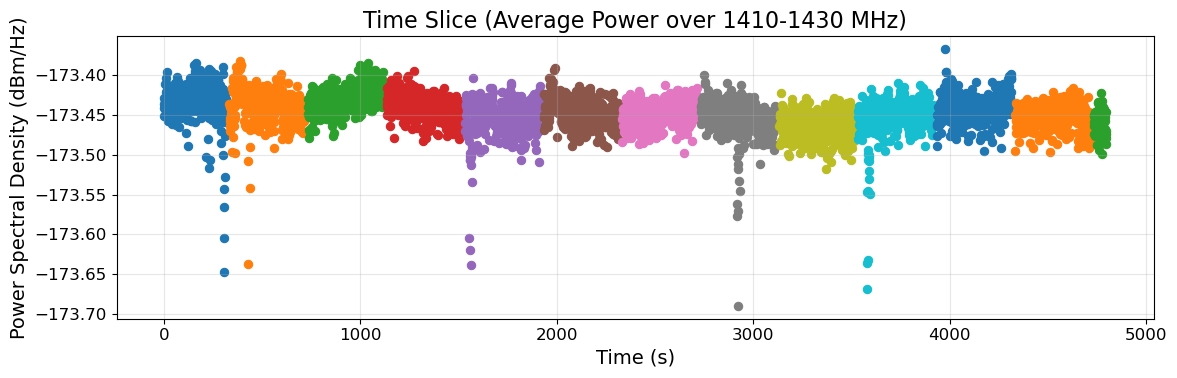

In [8]:
time_slice = np.nanmean(data[:, int(1410/2000*data.shape[1]):int(1430/2000*data.shape[1])], axis=1)
time_slice = np.array(time_slice, copy=True)
time_slice[time_slice < -174] = np.nan
plt.figure(figsize=(12, 4))
for start, end in zip(starts, ends):
    plt.scatter(time_axis[start:end], time_slice[start:end], lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Power Spectral Density (dBm/Hz)")
plt.title("Time Slice (Average Power over 1410-1430 MHz)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
chord_segments = []
for start, end in zip(starts, ends):
    # Also filter out the three time segments that are abnormally low power (likely due to calibration cycles)
    data_1420 = data[start:end, int(1420/2000*data.shape[1])]
    current_segment = data[start:end, chord_range][data_1420 > -174]
    print(f"Segment {start}-{end}: {current_segment.shape[0]} rows after filtering")
    chord_segments.append(current_segment)

# Cut first and last segments which are incomplete
chord_segments = chord_segments[1:12]

Segment 0-316: 316 rows after filtering
Segment 334-716: 382 rows after filtering
Segment 734-1116: 382 rows after filtering
Segment 1134-1516: 382 rows after filtering
Segment 1534-1916: 381 rows after filtering
Segment 1934-2316: 382 rows after filtering
Segment 2334-2716: 382 rows after filtering
Segment 2734-3116: 381 rows after filtering
Segment 3134-3516: 382 rows after filtering
Segment 3534-3916: 381 rows after filtering
Segment 3934-4316: 382 rows after filtering
Segment 4334-4716: 382 rows after filtering
Segment 4734-4800: 66 rows after filtering


## Functions

Kurtosis

In [10]:
def block_moments(data, ref_db, block=256):
    """One streaming pass: raw moments of x (dB) and of P (linear power).

    Blocks over the (small) time axis so peak RAM is ~block x n_freq, not the
    whole array. block=256 over (4800, 600000) float32 is ~0.6 GB per read.
    """
    n_time, n_freq = data.shape
    # dB-domain sums (of x - ref_db); float64 accumulators (np.zeros is f64)
    T1 = np.zeros(n_freq); T2 = np.zeros(n_freq)
    T3 = np.zeros(n_freq); T4 = np.zeros(n_freq)
    # linear-power sums (of P)
    S1 = np.zeros(n_freq); S2 = np.zeros(n_freq)
    S3 = np.zeros(n_freq); S4 = np.zeros(n_freq)
    M  = 0

    ln10_10 = np.float32(np.log(10) / 10)

    for i in range(0, n_time, block):
        sl = slice(i, min(i + block, n_time))
        x  = np.asarray(data[sl], dtype=np.float32)

        xc = x - np.float32(ref_db)                        # shift for stability
        x2 = xc * xc
        T1 += xc.sum(0, dtype=np.float64);      T2 += x2.sum(0, dtype=np.float64)
        T3 += (x2*xc).sum(0, dtype=np.float64); T4 += (x2*x2).sum(0, dtype=np.float64)

        P  = np.exp(xc * ln10_10)                          # == 10**(xc/10), faster
        P2 = P * P
        S1 += P.sum(0, dtype=np.float64);       S2 += P2.sum(0, dtype=np.float64)
        S3 += (P2*P).sum(0, dtype=np.float64);  S4 += (P2*P2).sum(0, dtype=np.float64)

        M += x.shape[0]

    return M, (T1, T2, T3, T4), (S1, S2, S3, S4)


def excess_kurtosis(M, A1, A2, A3, A4):
    """Excess kurtosis from raw (non-central) moment sums."""
    m1, m2, m3, m4 = A1/M, A2/M, A3/M, A4/M
    mu2 = m2 - m1**2
    mu4 = m4 - 4*m3*m1 + 6*m2*m1**2 - 3*m1**4
    return ((M-1)/((M-2)*(M-3))) * ((M+1) * mu4 / mu2**2 - 3*(M-1))

def excess_kurtosis_std(M):
    return np.sqrt(24*M*(M-1)**2 / ((M-3)*(M-2)*(M+3)*(M+5)))


Plotting

In [11]:
lines = H_lines["Frequency (MHz)"]
def chord_freq_to_index(freq_mhz):
    return int((freq_mhz - chord_min) / (chord_max - chord_min) * 360000)

def plot_band_traces(
        chord_data, center_freq=750, f_width=10, ylims=None,
        kurtosis=None, kurtosis_type="EK", kurtosis_bounds=[None, None], 
        t_traces=20, f_traces=1000, f_max=2000,
        lines=lines, title=None, ax=None):

    if chord_data.shape[1] != 360000:
        raise ValueError("Must provide a CHORD band slice of shape (n_time, 360000)")
    
    # --- frequency columns within the band ---
    f_min, f_max = center_freq - f_width/2, center_freq + f_width/2
    f_i_min = chord_freq_to_index(f_min)
    f_i_max = chord_freq_to_index(f_max)
    
    if f_traces == -1:
        f_idx = np.arange(f_i_min, f_i_max + 1)   # every bin in the band
    else:
        f_idx = np.unique(np.linspace(f_i_min, f_i_max, f_traces, dtype=int))
    f_range = np.linspace(f_min, f_max, f_idx.size)

    # --- sample of clean time rows ---

    if t_traces == -1:
        t_idx = np.arange(chord_data.shape[0])
    else:
        t_idx = np.random.choice(np.arange(chord_data.shape[0]), size=min(t_traces, chord_data.shape[0]), replace=False)  # random sample of rows
    t_idx = np.sort(t_idx)

    # --- the sub-block: every selected row x every selected column ---
    data_slice = chord_data[np.ix_(t_idx, f_idx)]

    # --- axes: add a kurtosis panel underneath when an array is supplied ---
    show_kurtosis = kurtosis is not None
    ax_k = None
    if ax is None:
        if show_kurtosis:
            _, (ax, ax_k) = plt.subplots(
                2, 1, figsize=(8, 5), sharex=True,
                gridspec_kw={"height_ratios": [2, 2]},
            )
            p_001, p_999 = kurtosis_bounds[0], kurtosis_bounds[1]
        else:
            _, ax = plt.subplots(figsize=(8, 4))

    # --- one scatter series per sampled time trace ---
    for row, t in zip(data_slice, t_idx):
        ax.scatter(f_range, row, s=4, alpha=0.3, label=f"t={t}")

    ax.set_ylabel("Power (dBm/Hz)", fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    else:
        ax.set_title(f"{data_slice.shape[0]} time traces near {center_freq} MHz "
                    f"({center_freq - f_width/2:g}-{center_freq + f_width/2:g} MHz)", fontsize=18)
    if ylims is not None:
        ax.set_ylim(ylims)
    ax.grid(alpha=0.3)

    # --- kurtosis panel (use the precomputed values for this band) ---
    if ax_k is not None:

        if kurtosis_type == "EK":
            #ax_k.plot(f_range, np.clip(np.asarray(kurtosis)[f_idx], p_001*1.2, p_999*1.2),color="firebrick", lw=1)
            ax_k.plot(f_range, np.asarray(kurtosis)[f_idx]),
            # ax_k.set_ylim(p_001*1.2, p_999*1.2)
            ax_k.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.7)  # normal reference
            ax_k.set_ylabel("Excess\nKurtosis", fontsize=14)
        else:
            ax_k.plot(f_range, np.clip(np.asarray(kurtosis)[f_idx], 0.1, 2.9),color="firebrick", lw=1)
            ax_k.axhline(1, color="gray", lw=0.8, ls="--", alpha=0.7)  # normal reference
            ax_k.set_ylim(0, 3)
            ax_k.set_ylabel("Spectral\nKurtosis", fontsize=14)


        ax_k.axhline(p_001, color="purple", ls="--", lw=1, alpha=0.8)
        ax_k.axhline(p_999, color="purple", ls="--", lw=1, alpha=0.8)
        ax_k.set_xlabel("Frequency (MHz)", fontsize=14)
        ax_k.grid(alpha=0.3)
    else:
        ax.set_xlabel("Frequency (MHz)", fontsize=14)

    # --- mark spectral lines that fall inside the band ---
    if lines is not None:
        lines = np.asarray(lines, dtype=float)
        f_lo, f_hi = center_freq - f_width/2, center_freq + f_width/2
        in_band = lines[(lines >= f_lo) & (lines <= f_hi)]
        for axx in (ax, ax_k):
            if axx is None:
                continue
            for L in in_band:
                axx.axvline(L, color="black", ls="--", lw=0.8, alpha=0.6)

    return data_slice, f_range, t_idx

## Compute Kurtosis for the full range

In [13]:
chord_segments[0].shape

(382, 360000)

In [14]:
# --- accumulate once ---
EK_dB = np.zeros((len(chord_segments), chord_segments[0].shape[1]), dtype=np.float64)
EK_P = np.zeros((len(chord_segments), chord_segments[0].shape[1]), dtype=np.float64)
SK = np.zeros((len(chord_segments), chord_segments[0].shape[1]), dtype=np.float64)
for i, segment in enumerate(chord_segments):
    M, T, S = block_moments(segment, -173, block=256)
    T1, T2, T3, T4 = T
    S1, S2, S3, S4 = S

    # --- three statistics over frequency ---
    EK_dB[i] = excess_kurtosis(M, T1, T2, T3, T4)          # kurtosis of dB power
    EK_P[i]  = excess_kurtosis(M, S1, S2, S3, S4)          # kurtosis of linear power

    N, d = 2500*15/16, 1
    SK[i] = (N*M*d + 1) / (M - 1) * (M * S2 / S1**2 - 1)



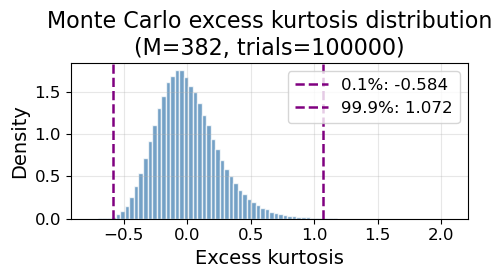

In [73]:
# Monte Carlo excess kurtosis samples for M=4581 (vectorized)
n_trials = 100000
n_samples = 382

rng = np.random.default_rng(0)  # optional seed for reproducibility
samples = rng.standard_normal((n_trials, n_samples))
ek = stats.kurtosis(samples, axis=1, fisher=True, bias=False)

p_001, p_999 = np.percentile(ek, [0.1, 99.9])
p_10, p_90 = np.percentile(ek, [10, 90])

plt.figure(figsize=(5, 3))
plt.hist(ek, bins=80, density=True, alpha=0.75, color="steelblue", edgecolor="white")
plt.axvline(p_001, color="purple", linestyle="--", linewidth=1.8, label=f"0.1%: {p_001:.3f}")
plt.axvline(p_999, color="purple", linestyle="--", linewidth=1.8, label=f"99.9%: {p_999:.3f}")
plt.xlabel("Excess kurtosis")
plt.ylabel("Density")
plt.title(f"Monte Carlo excess kurtosis distribution\n(M={n_samples}, trials={n_trials})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
#plt.savefig("../../thesis/plots/rfi/excess_kurtosis_monte_carlo.png", dpi=300)
plt.show()


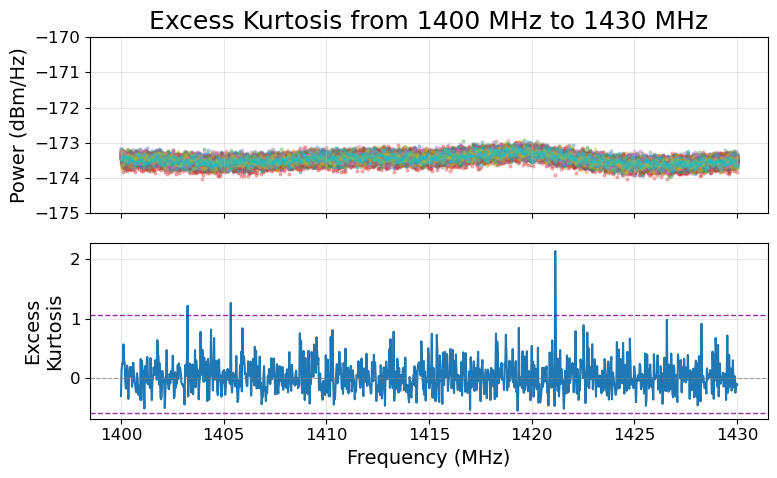

In [78]:
data_slice, freq_mhz, t_idx = plot_band_traces(
    chord_segments[0], center_freq=1415, f_width=30, ylims=(-175, -170),
    f_traces=1000, t_traces=50, 
    title="Excess Kurtosis from 1400 MHz to 1430 MHz", lines=None, 
    kurtosis=EK_P[0], kurtosis_bounds=[p_001, p_999], kurtosis_type="EK")
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/1400_band_excess_kurtosis.png", dpi=300)
plt.show()

Fraction of clean excess kurtosis values between simulated 0.1% and 99.9% thresholds: 99.5%


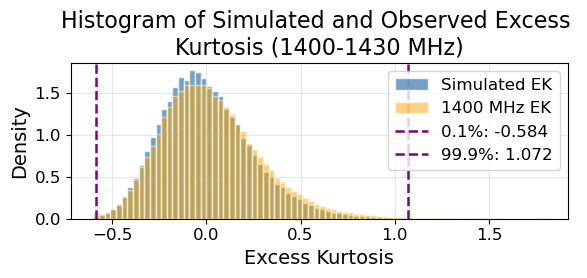

In [115]:
clean_EK = EK_P[:, chord_freq_to_index(1400):chord_freq_to_index(1430)].flatten()

clean_EK_count = np.sum((clean_EK > p_001) & (clean_EK < p_999))/len(clean_EK)
print(f"Fraction of clean excess kurtosis values between simulated 0.1% and 99.9% thresholds: {clean_EK_count*100:.1f}%")

plt.figure(figsize=(6, 3))
plt.hist(
    ek, bins=80, range=(-0.6, 1.8), density=True, 
    alpha=0.75, color="steelblue", edgecolor="white",
    label="Simulated EK"
)
plt.hist(
    np.clip(clean_EK, -0.6, 1.8), bins=80, range=(-0.6, 1.8), density=True, 
    alpha=0.5, color="orange", edgecolor="white",
    label="1400 MHz EK"
)
plt.axvline(p_001, color="purple", linestyle="--", linewidth=1.8, label=f"0.1%: {p_001:.3f}")
plt.axvline(p_999, color="purple", linestyle="--", linewidth=1.8, label=f"99.9%: {p_999:.3f}")
plt.legend()
plt.xlabel("Excess Kurtosis")
plt.ylabel("Density")
plt.title("Histogram of Simulated and Observed\nExcess Kurtosis (1400-1430 MHz)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/simulated_and_observed_EK_histogram.png", dpi=300)
plt.show()

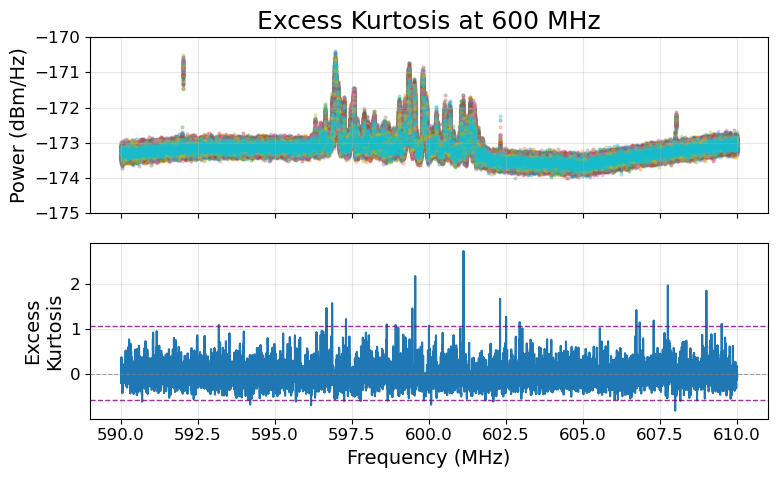

In [91]:
data_slice, freq_mhz, t_idx = plot_band_traces(
    chord_segments[1], center_freq=600, f_width=20, ylims=(-175, -170),
    f_traces=-1, t_traces=100, 
    title="Excess Kurtosis at 600 MHz", lines=None, 
    kurtosis=EK_P[1], kurtosis_bounds=[p_001, p_999], kurtosis_type="EK")
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/600MHz_sample_EK.png", dpi=300)
plt.show()

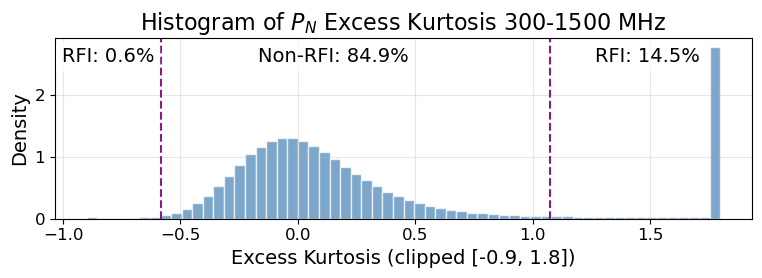

In [120]:
fig, ax = plt.subplots(figsize=(8, 3))
clean_g2_P = (EK_P > p_001) & (EK_P < p_999)
lower_rfi = np.sum(EK_P <= p_001)/EK_P.size
upper_rfi = np.sum(EK_P >= p_999)/EK_P.size
non_rfi = np.sum(clean_g2_P)/EK_P.size

ax.hist(
    np.clip(EK_P.flatten(), -0.9, 1.8),
    bins=60,
    range=(-0.9, 1.8),
    density=True,
    alpha=0.7,
    color="steelblue",
    edgecolor="white",
    label="full data"
)
ax.axvline(p_001, color="purple", linestyle="--", linewidth=1.5, alpha=0.9)
ax.axvline(p_999, color="purple", linestyle="--", linewidth=1.5, alpha=0.9)
# ax.text(
#     0.8, 0.95, f"Samples={M}",
#     transform=ax.transAxes, ha="center", va="top",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none")
# )
ax.text(
    0.01, 0.95, f"RFI: {lower_rfi*100:.1f}%",
    transform=ax.transAxes, ha="left", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none")
)
ax.text(
    0.4, 0.95, f"Non-RFI: {non_rfi*100:.1f}%",
    transform=ax.transAxes, ha="center", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none")
)
ax.text(
    0.85, 0.95, f"RFI: {upper_rfi*100:.1f}%",
    transform=ax.transAxes, ha="center", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none")
)
ax.set_xlabel("Excess Kurtosis (clipped [-0.9, 1.8])")
ax.set_ylabel("Density")
ax.set_title("Histogram of $P_N$ Excess Kurtosis 300-1500 MHz")
# ax.set_ylim(0, 5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/excess_kurtosis_histogram.png", dpi=300)
plt.show()

## Get empirical shape parameter

In [15]:
from scipy.stats import gaussian_kde

SK_clean = SK[:, chord_freq_to_index(1400):chord_freq_to_index(1430)].flatten()

x = np.clip(SK_clean, 0, 2)
grid = np.linspace(x.min(), x.max(), 2000)

kde = gaussian_kde(x)
mode_sk = grid[np.argmax(kde(grid))]

mode_sk

np.float64(1.0407104832483614)

In [16]:
SK_cal = np.zeros((len(chord_segments), chord_segments[0].shape[1]), dtype=np.float64)
for i, segment in enumerate(chord_segments):
    M, T, S = block_moments(segment, -173, block=256)
    T1, T2, T3, T4 = T
    S1, S2, S3, S4 = S

    N, d = 2500*15/16, 1/mode_sk
    SK_cal[i] = (N*M*d + 1) / (M - 1) * (M * S2 / S1**2 - 1)

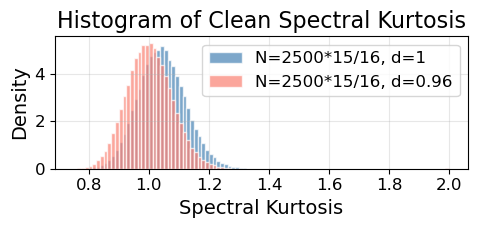

In [17]:
SK_cal_clean = SK_cal[:, chord_freq_to_index(1400):chord_freq_to_index(1430)].flatten()

plt.figure(figsize=(5, 2.5))
plt.hist(np.clip(SK_clean, 0, 2), bins=100, range=(0.75, 2), density=True, alpha=0.7, color="steelblue", edgecolor="white", label="N=2500*15/16, d=1")
plt.hist(np.clip(SK_cal_clean, 0, 2), bins=100, range=(0.75, 2), density=True, alpha=0.7, color="salmon", edgecolor="white", label=f"N=2500*15/16, d={1/mode_sk:.2f}")
plt.legend()
plt.xlabel("Spectral Kurtosis")
plt.ylabel("Density")
plt.title("Histogram of Clean Spectral Kurtosis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/hist_setting_sk_p.png", dpi=300)
plt.show()

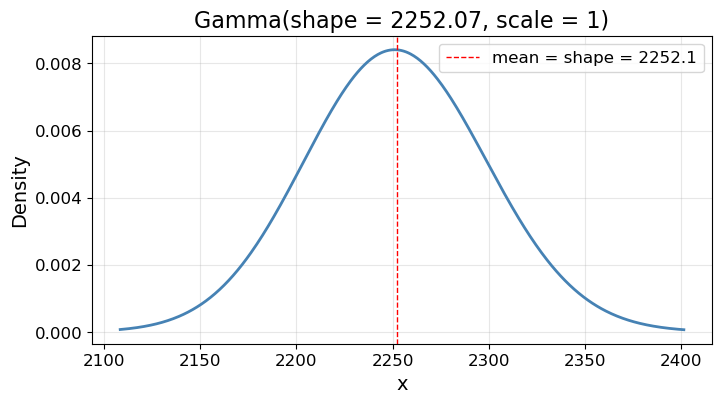

In [18]:
Nd = N*d

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

shape, scale = float(Nd), 1.0

# span the bulk of the distribution (0.1st–99.9th percentile)
x = np.linspace(stats.gamma.ppf(0.001, shape, scale=scale),
                stats.gamma.ppf(0.999, shape, scale=scale), 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, stats.gamma.pdf(x, shape, scale=scale), lw=2, color="steelblue")
ax.axvline(shape, color="r", ls="--", lw=1, label=f"mean = shape = {shape:.1f}")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title(f"Gamma(shape = {shape:.2f}, scale = 1)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


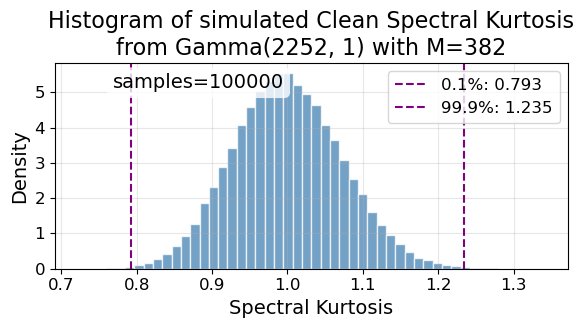

In [20]:
rng = np.random.default_rng()

Nd = N*d
gamma_samples = rng.gamma(shape=Nd, scale=1.0, size=(382, 100000))
M_gamma = gamma_samples.shape[0]
S1_gamma = gamma_samples.sum(axis=0)
S2_gamma = np.square(gamma_samples).sum(axis=0)

SK_gamma = ((Nd * M_gamma + 1.0) / (M_gamma - 1.0)) * (M_gamma * S2_gamma / S1_gamma**2 - 1.0)
SK_001, SK_999 = np.percentile(SK_gamma, [0.1, 99.9])
SK_005, SK_995 = np.percentile(SK_gamma, [0.5, 99.5])
SK_01, SK_99 = np.percentile(SK_gamma, [1, 99])
SK_05, SK_95 = np.percentile(SK_gamma, [5, 95])
SK_10, SK_90 = np.percentile(SK_gamma, [10, 90])

plt.figure(figsize=(6, 3.5))
plt.hist(SK_gamma, density=True, bins=50, alpha=0.75, color="steelblue", edgecolor="white")
plt.axvline(SK_001, color="purple", linestyle="--", linewidth=1.5, label=f"0.1%: {SK_001:.3f}")
plt.axvline(SK_999, color="purple", linestyle="--", linewidth=1.5, label=f"99.9%: {SK_999:.3f}")
plt.text(0.28, 0.95, f"samples={gamma_samples.shape[1]}", transform=plt.gca().transAxes, ha="center", va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))
plt.legend()
plt.xlabel("Spectral Kurtosis")
plt.ylabel("Density")
plt.title(f"Histogram of simulated Clean Spectral Kurtosis\nfrom Gamma({round(Nd)}, 1) with M={M_gamma}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Fraction of clean spectral kurtosis values between simulated 0.1% and 99.9% thresholds: 99.639%


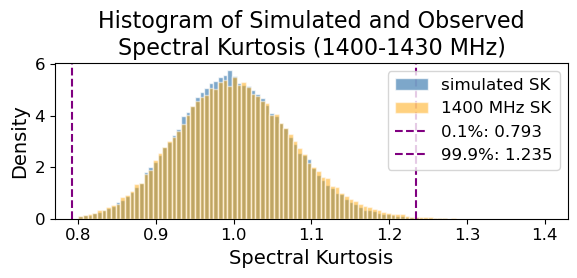

In [21]:
clean_SK_count = np.sum((SK_cal_clean > SK_001) & (SK_cal_clean < SK_999))/len(SK_cal_clean)
print(f"Fraction of clean spectral kurtosis values between simulated 0.1% and 99.9% thresholds: {clean_SK_count*100:.3f}%")

plt.figure(figsize=(6, 3))
plt.hist(SK_gamma, density=True, bins=100, range=(0.8, 1.4), alpha=0.7, color="steelblue", edgecolor="white", label="simulated SK")
plt.hist(np.clip(SK_cal_clean, 0, 2), bins=100, range=(0.8, 1.4), density=True, alpha=0.5, color="orange", edgecolor="white", label=f"1400 MHz SK")
plt.axvline(SK_001, color="purple", linestyle="--", linewidth=1.5, label=f"0.1%: {SK_001:.3f}")
plt.axvline(SK_999, color="purple", linestyle="--", linewidth=1.5, label=f"99.9%: {SK_999:.3f}")
plt.legend()
plt.xlabel("Spectral Kurtosis")
plt.ylabel("Density")
plt.title("Histogram of Simulated and Observed\nSpectral Kurtosis (1400-1430 MHz)")
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/spectral_kurtosis_all_time.png", dpi=300)
plt.show()

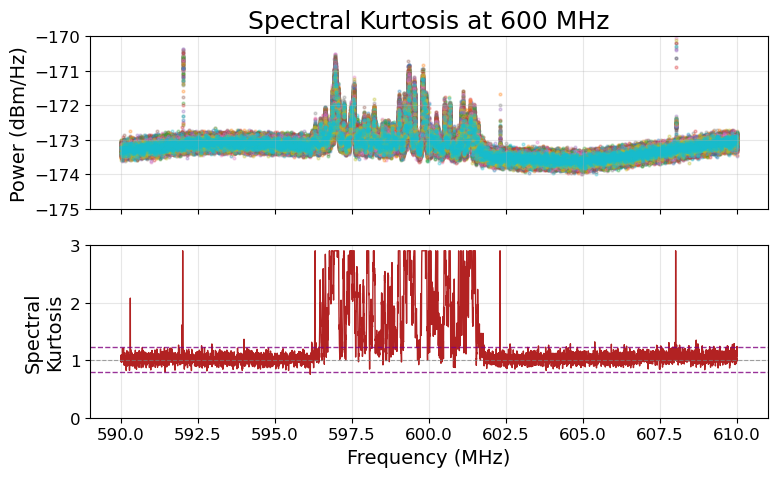

In [22]:
data_slice, freq_mhz, t_idx = plot_band_traces(
    chord_segments[0], center_freq=600, f_width=20, ylims=(-175, -170),
    f_traces=-1, t_traces=100, 
    title="Spectral Kurtosis at 600 MHz", lines=None, 
    kurtosis=SK_cal[0], kurtosis_bounds=[SK_001, SK_999], kurtosis_type="SK")
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/600MHz_sample_SK.png", dpi=300)
plt.show()

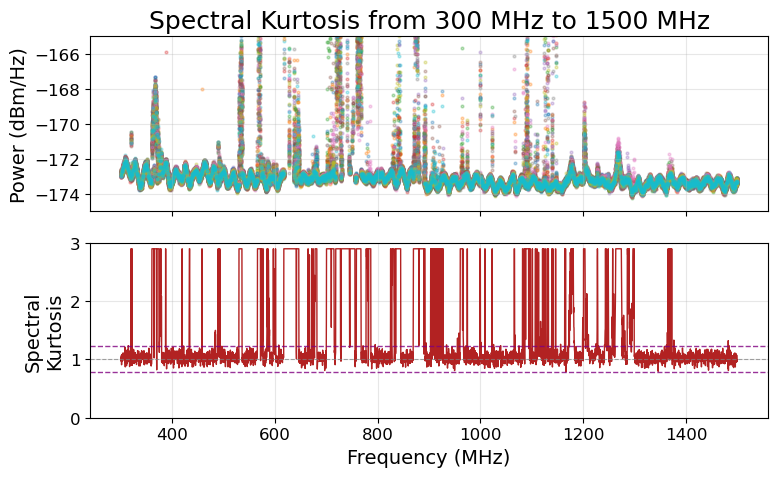

In [23]:
data_slice, freq_mhz, t_idx = plot_band_traces(
    chord_segments[0], center_freq=900, f_width=1200-1, ylims=(-175, -165),
    f_traces=4000, t_traces=30, 
    title="Spectral Kurtosis from 300 MHz to 1500 MHz", lines=None, 
    kurtosis=SK_cal[0], kurtosis_bounds=[SK_001, SK_999], kurtosis_type="SK")
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/SK_plot_full_band.png", dpi=300)
plt.show()

Fraction of spectral kurtosis values below 0.1% threshold: 0.1%
Fraction of spectral kurtosis values above 99.9% threshold: 24.4%
Fraction of spectral kurtosis values within 0.1% and 99.9% thresholds: 75.5%


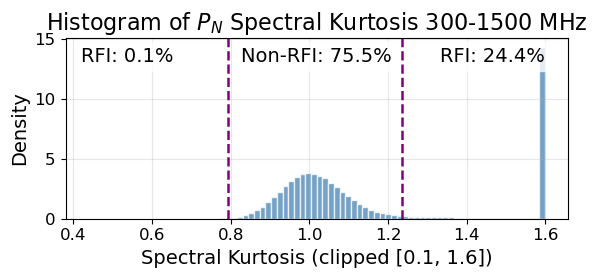

In [24]:
sk_vals = SK_cal.flatten()
lower_rfi = np.sum(sk_vals <= SK_001)/sk_vals.size
upper_rfi = np.sum(sk_vals >= SK_999)/sk_vals.size
non_rfi = np.sum((sk_vals > SK_001) & (sk_vals < SK_999))/sk_vals.size
print(f"Fraction of spectral kurtosis values below 0.1% threshold: {lower_rfi*100:.1f}%")
print(f"Fraction of spectral kurtosis values above 99.9% threshold: {upper_rfi*100:.1f}%")
print(f"Fraction of spectral kurtosis values within 0.1% and 99.9% thresholds: {non_rfi*100:.1f}%")

plt.figure(figsize=(6, 3))
plt.hist(
    np.clip(sk_vals, 0.1, 1.6), bins=80, density=True, alpha=0.75, color="steelblue", edgecolor="white")
plt.axvline(SK_001, color="purple", linestyle="--", linewidth=1.8, label=f"0.1%: {SK_001:.3f}")
plt.axvline(SK_999, color="purple", linestyle="--", linewidth=1.8, label=f"99.9%: {SK_999:.3f}")
plt.text(0.03, 0.95, f"RFI: {lower_rfi*100:.1f}%", transform=plt.gca().transAxes, ha="left", va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))
plt.text(0.5, 0.95, f"Non-RFI: {non_rfi*100:.1f}%", transform=plt.gca().transAxes, ha="center", va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))
plt.text(0.85, 0.95, f"RFI: {upper_rfi*100:.1f}%", transform=plt.gca().transAxes, ha="center", va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))
plt.xlabel("Spectral Kurtosis (clipped [0.1, 1.6])")
plt.ylabel("Density")
plt.title("Histogram of $P_N$ Spectral Kurtosis 300-1500 MHz")
plt.grid(alpha=0.3)
# plt.ylim(0, 5)
# plt.legend()
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/spectral_kurtosis_histogram.png", dpi=300)
plt.show()

Average pairwise agreement of RFI flags across 11 time segments: 93.7%
Standard deviation of pairwise agreement: 1.0%


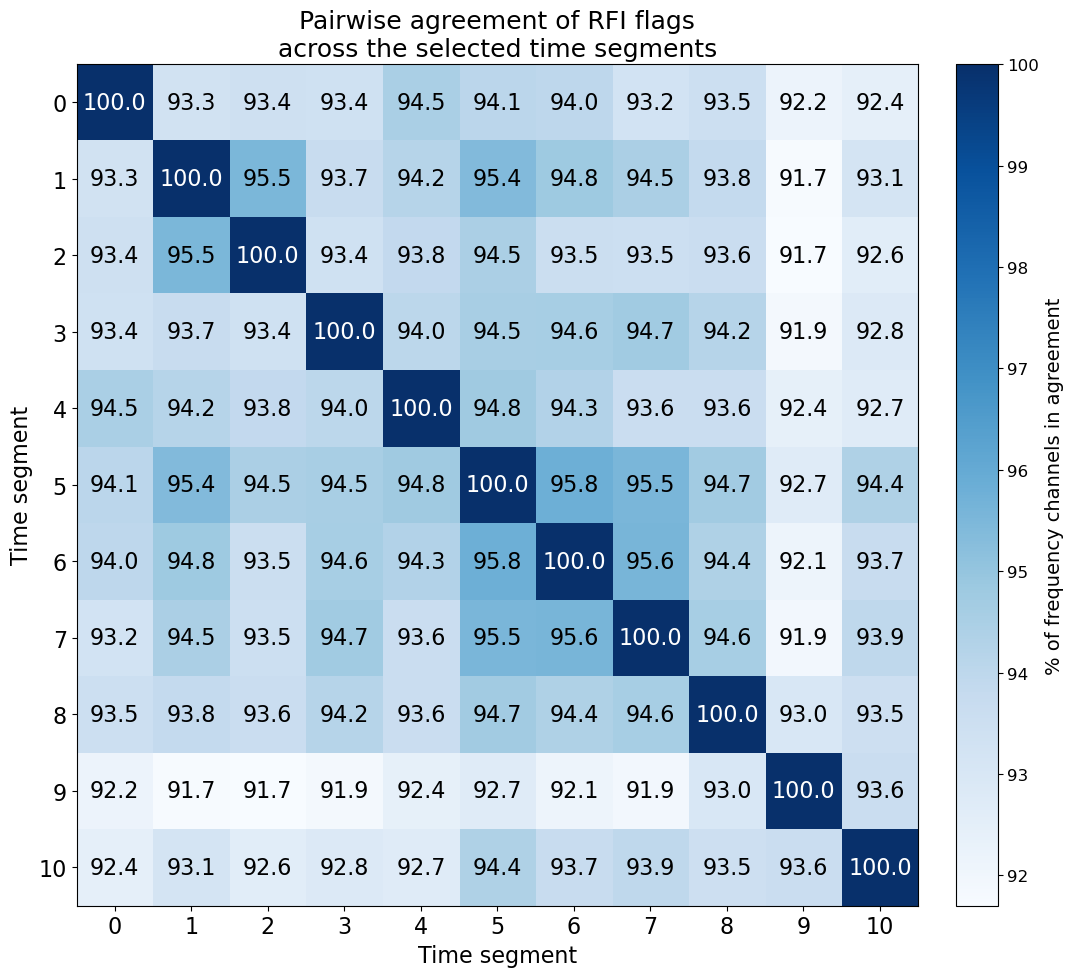

In [25]:
# Pairwise per-channel agreement of the RFI flags across the 11 time segments.
# RFI has shape (n_segments, n_channels); entry (i, j) is the fraction of
# channels on which segment i and segment j assign the same flag.
clean_spectrum = (SK_cal > SK_001) & (SK_cal < SK_999)
n_sets = clean_spectrum.shape[0]
comparisons = range(n_sets)
agree = np.array([[np.mean(clean_spectrum[i] == clean_spectrum[j]) for j in comparisons]
                  for i in comparisons])
avg_agreement = np.mean(agree[np.triu_indices(n_sets, k=1)])
std_agreement = np.std(agree[np.triu_indices(n_sets, k=1)])
print(f"Average pairwise agreement of RFI flags across {n_sets} time segments: {avg_agreement*100:.1f}%")
print(f"Standard deviation of pairwise agreement: {std_agreement*100:.1f}%")

#comparisons = [2, 5, 6, 9]
agree = np.array([[np.mean(clean_spectrum[i] == clean_spectrum[j]) for j in comparisons]
                  for i in comparisons])

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(agree * 100, cmap="Blues", vmin=agree.min() * 100, vmax=100)

ax.set_xticks(range(len(comparisons)))
ax.set_yticks(range(len(comparisons)))
ax.set_xticklabels(comparisons, fontsize=16)
ax.set_yticklabels(comparisons, fontsize=16)
ax.set_xlabel("Time segment", fontsize=16)
ax.set_ylabel("Time segment", fontsize=16)
ax.set_title("Pairwise agreement of RFI flags\nacross the selected time segments", fontsize=18)

thr = (agree.min() + 1) / 2 * 100  # text contrast against the Blues colormap
for i in range(len(comparisons)):
    for j in range(len(comparisons)):
        ax.text(j, i, f"{agree[i, j] * 100:.1f}", ha="center", va="center",
                color="white" if agree[i, j] * 100 > thr else "black", fontsize=16)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% of frequency channels in agreement")
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/rfi_flag_agreement.png", dpi=300)
plt.show()

## Characterizing RRL Lines

In [26]:
clean_spectrum

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(11, 360000))

In [27]:
# Consider spectrum clean if 50% or more of the time segments agree that it is clean.
combined_clean_spectrum = (clean_spectrum.mean(axis=0) > 0.5).astype(int)
np.mean(combined_clean_spectrum)

np.float64(0.7619472222222222)

In [28]:
combined_clean_spectrum

array([1, 1, 1, ..., 1, 1, 1], shape=(360000,))

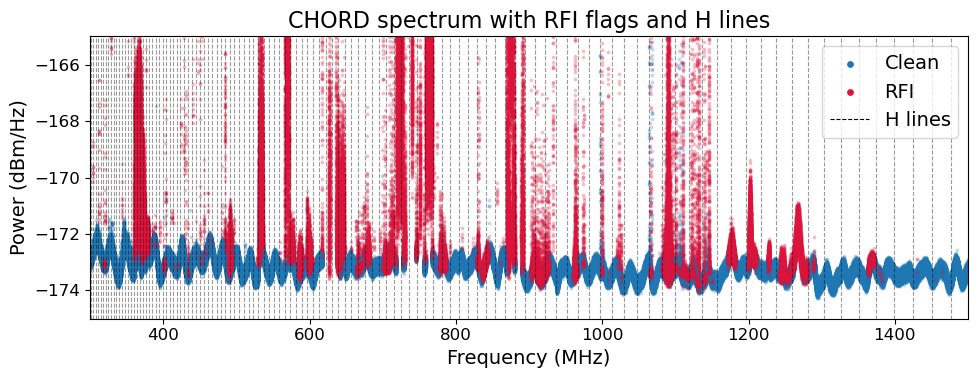

In [29]:
data_slice = np.array([chord_segments[i][10, ::4] for i in range(len(chord_segments))])
freq_mhz = np.linspace(chord_min, chord_max, data_slice.shape[1])

# Match frequency decimation (::4) used in data_slice
clean_mask = combined_clean_spectrum[::4].astype(bool)
rfi_mask = ~clean_mask

plt.figure(figsize=(10, 4))
for row in data_slice:
    plt.scatter(freq_mhz[clean_mask], row[clean_mask], s=3, alpha=0.2, color="C0")
    plt.scatter(freq_mhz[rfi_mask], row[rfi_mask], s=3, alpha=0.2, color="crimson")

for line in H_lines["Frequency (MHz)"]:
    if chord_min <= line <= chord_max:
        plt.axvline(line, color="black", ls="--", lw=0.8, alpha=0.4)

# legend proxies
plt.scatter([], [], s=15, color="C0", label="Clean")
plt.scatter([], [], s=15, color="crimson", label="RFI")
plt.plot([], [], ls="--", color="black", label="H lines", lw=0.8)

plt.xlim(chord_min, chord_max)
plt.ylim(-175, -165)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm/Hz)")
plt.title("CHORD spectrum with RFI flags and H lines")
plt.legend(loc="upper right", frameon=True, fontsize=14)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/rfi_flagged_spectrum.png", dpi=300)
plt.show()

In [30]:
v_kms = 100.0
c_kms = 299792.458

# Frequency shift for a 100 km/s radial velocity
H_lines["delta_f_MHz_100kms"] = H_lines["Frequency (MHz)"] * (v_kms / c_kms)
H_lines["delta_f_kHz_100kms"] = H_lines["delta_f_MHz_100kms"] * 1e3
H_lines

,Transition,Species,Line,Frequency (MHz),delta_f_MHz_100kms,delta_f_kHz_100kms
0,H164alpha,H,H164,1477.335105,0.492786,492.785948
1,H165alpha,H,H165,1450.716777,0.483907,483.907029
2,H166alpha,H,H166,1424.734102,0.475240,475.240142
3,H167alpha,H,H167,1399.368217,0.466779,466.778993
4,H168alpha,H,H168,1374.600927,0.458518,458.517514
...,...,...,...,...,...,...
111,H275alpha,H,H275,314.489820,0.104903,104.902512
112,H276alpha,H,H276,311.089945,0.103768,103.768436
113,H277alpha,H,H277,307.738901,0.102651,102.650648
114,H278alpha,H,H278,304.435814,0.101549,101.548857


In [31]:
# Frequency of each of the 36000 bins
import numpy as np
freqs = np.linspace(chord_min, chord_max, combined_clean_spectrum.size)   # 300 -> 1500 MHz
clean = combined_clean_spectrum.astype(float)                            # True/False -> 1.0/0.0

def line_clean_score(f0, sigma_mhz, clean_spectrum=clean, n_sigma=5):
    """Gaussian-weighted fraction of clean bins around a line center.

    Returns a value in [0, 1]: 1.0 = fully clean within the line width,
    0.0 = fully flagged. sigma_mhz is the 100 km/s width for this line.
    ``clean_spectrum`` is the per-bin clean array to score (defaults to the
    combined spectrum); pass a different aggregation/threshold to score it.
    """
    # only touch bins within +/- n_sigma of the center (the Gaussian is ~0 beyond)
    lo = np.searchsorted(freqs, f0 - n_sigma * sigma_mhz)
    hi = np.searchsorted(freqs, f0 + n_sigma * sigma_mhz)
    if hi <= lo:
        return np.nan                       # line outside the 300-1500 MHz range
    w = np.exp(-0.5 * ((freqs[lo:hi] - f0) / sigma_mhz) ** 2)
    return np.sum(w * clean_spectrum[lo:hi]) / np.sum(w)

H_lines["clean_score"] = [
    line_clean_score(f0, sigma, clean_spectrum=clean, n_sigma=3)
    for f0, sigma in zip(H_lines["Frequency (MHz)"], H_lines["delta_f_MHz_100kms"])
]

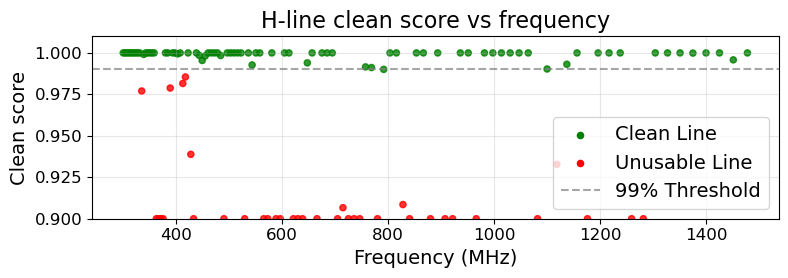

In [32]:
plt.figure(figsize=(8, 3))
h = H_lines.sort_values("Frequency (MHz)")
threshold = 0.99
clean = h["clean_score"] >= threshold

#plt.plot(h["Frequency (MHz)"], np.clip(h["clean_score"], 0.9, 1), lw=1.5, color="steelblue")
plt.scatter(h["Frequency (MHz)"], np.clip(h["clean_score"], 0.9, 1), s=20, 
            color=clean.map({True: "green", False: "red"}), alpha=0.8)
plt.scatter([], [], s=20, color="green", label=f"Clean Line")
plt.scatter([], [], s=20, color="red", label=f"Unusable Line")
plt.axhline(threshold, color="gray", ls="--", lw=1.5, alpha=0.7, label="99% Threshold")
# plt.plot(h["Frequency (MHz)"], h["clean_score_all"], lw=1.5, color="orange")
# plt.scatter(h["Frequency (MHz)"], h["clean_score_all"], s=20, color="orange", alpha=0.8, label="Clean score (all segments)")

plt.xlabel("Frequency (MHz)")
plt.ylabel("Clean score")
plt.title("H-line clean score vs frequency")
plt.grid(alpha=0.3)
plt.legend(loc="lower right", frameon=True, fontsize=14)
plt.tight_layout()
# plt.yscale(
#     "function",
#     functions=(
#         lambda y: np.tan(np.pi * (np.clip(y, 1e-6, 1 - 1e-6) - 0.5)),  # forward: data -> screen
#         lambda z: 0.5 + np.arctan(z) / np.pi,                          # inverse: screen -> data
#     ),
# )
# plt.yscale("logit")

plt.ylim(0.9, 1.01)
plt.savefig("../../thesis/plots/rfi/h_line_clean_score.png", dpi=300)
plt.show()

In [33]:
n = len(H_lines)

H_lines.loc[: n//3 - 1, "region"] = "high frequency"
H_lines.loc[n//3 : 2*n//3 - 1, "region"] = "mid frequency"
H_lines.loc[2*n//3 :, "region"] = "low frequency"

H_lines['clean'] = H_lines['clean_score'] >= threshold
H_lines.groupby("region").agg({
    "clean": ["sum", "count", "mean"],
    "Frequency (MHz)": ["min", "max"]
})

clean                 Frequency (MHz)             
                 sum count      mean             min          max
region                                                           
high frequency    27    38  0.710526      803.801656  1477.335105
low frequency     29    39  0.743590      301.179830   466.896930
mid frequency     23    39  0.589744      472.745292   791.952097

In [35]:
output_csv = "../../rfi_data/H_lines_with_clean_scores.csv"
H_lines.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")
H_lines.head(10)

Saved: ../../rfi_data/H_lines_with_clean_scores.csv


,Transition,Species,Line,Frequency (MHz),delta_f_MHz_100kms,delta_f_kHz_100kms,clean_score,region,clean
0,H164alpha,H,H164,1477.335105,0.492786,492.785948,1.000000,high frequency,True
1,H165alpha,H,H165,1450.716777,0.483907,483.907029,0.995812,high frequency,True
2,H166alpha,H,H166,1424.734102,0.475240,475.240142,1.000000,high frequency,True
3,H167alpha,H,H167,1399.368217,0.466779,466.778993,1.000000,high frequency,True
4,H168alpha,H,H168,1374.600927,0.458518,458.517514,0.999891,high frequency,True
5,H169alpha,H,H169,1350.414681,0.450450,450.449851,1.000000,high frequency,True
6,H170alpha,H,H170,1326.792537,0.442570,442.570352,1.000000,high frequency,True
7,H171alpha,H,H171,1303.718144,0.434874,434.873563,1.000000,high frequency,True
8,H172alpha,H,H172,1281.175719,0.427354,427.354219,0.799972,high frequency,False
9,H173alpha,H,H173,1259.150019,0.420007,420.007237,0.594019,high frequency,False


In [37]:
H_lines[H_lines.clean]["Frequency (MHz)"].to_numpy()

array([1477.335105  , 1450.716777  , 1424.734102  , 1399.368217  ,
       1374.600927  , 1350.414681  , 1326.792537  , 1303.718144  ,
       1237.626322  , 1216.590408  , 1196.028536  , 1156.27425   ,
       1137.056593  , 1099.88025   , 1064.30706   , 1047.094715  ,
       1030.251531  , 1013.767665  ,  997.6335837 ,  981.84006   ,
        951.2392103 ,  936.4148375 ,  893.7491117 ,  866.7356494 ,
        853.6364817 ,  815.8887989 ,  803.8016564 ,  791.9520966 ,
        768.9426596 ,  757.7716677 ,  695.0922388 ,  685.3252067 ,
        675.7403087 ,  657.100129  ,  648.0367432 ,  613.4051033 ,
        605.1345288 ,  581.1978145 ,  558.5070926 ,  551.2063928 ,
        544.0323853 ,  536.9823337 ,  523.2435042 ,  516.5495982 ,
        509.9693884 ,  503.5004709 ,  497.1405028 ,  484.7383357 ,
        478.6917387 ,  472.7452917 ,  466.8969297 ,  461.1446387 ,
        455.486454  ,  449.9204591 ,  444.4447839 ,  439.0576039 ,
        423.409442  ,  408.4961414 ,  403.6808877 ,  398.94087

## Results for different thresholds

In [331]:
SK_cal_999 = (SK_cal < SK_999) & (SK_cal > SK_001)
SK_cal_995 = (SK_cal < SK_995) & (SK_cal > SK_005)
SK_cal_990 = (SK_cal < SK_99) & (SK_cal > SK_01)
SK_cal_950 = (SK_cal < SK_95) & (SK_cal > SK_05)
SK_cal_900 = (SK_cal < SK_90) & (SK_cal > SK_10)

SK_cal_999_all = SK_cal_999.all(axis=0).astype(float)
SK_cal_995_all = SK_cal_995.all(axis=0).astype(float)
SK_cal_990_all = SK_cal_990.all(axis=0).astype(float)
SK_cal_950_all = SK_cal_950.all(axis=0).astype(float)
SK_cal_900_all = SK_cal_900.all(axis=0).astype(float)
agg_all = [SK_cal_999_all, SK_cal_995_all, SK_cal_990_all, SK_cal_950_all, SK_cal_900_all]

SK_cal_999_any = SK_cal_999.any(axis=0).astype(float)
SK_cal_995_any = SK_cal_995.any(axis=0).astype(float)
SK_cal_990_any = SK_cal_990.any(axis=0).astype(float)
SK_cal_950_any = SK_cal_950.any(axis=0).astype(float)
SK_cal_900_any = SK_cal_900.any(axis=0).astype(float)
agg_any = [SK_cal_999_any, SK_cal_995_any, SK_cal_990_any, SK_cal_950_any, SK_cal_900_any]

SK_cal_999_mean = (np.mean(SK_cal_999, axis=0) > 0.5).astype(float)
SK_cal_995_mean = (np.mean(SK_cal_995, axis=0) > 0.5).astype(float)
SK_cal_990_mean = (np.mean(SK_cal_990, axis=0) > 0.5).astype(float)
SK_cal_950_mean = (np.mean(SK_cal_950, axis=0) > 0.5).astype(float)
SK_cal_900_mean = (np.mean(SK_cal_900, axis=0) > 0.5).astype(float)
agg_mean = [SK_cal_999_mean, SK_cal_995_mean, SK_cal_990_mean, SK_cal_950_mean, SK_cal_900_mean]

scores_by_threshold = pd.DataFrame({
    "freq": H_lines["Frequency (MHz)"],
    "sigma": H_lines["delta_f_MHz_100kms"]
})

# Score all 9 permutations: 3 cross-segment aggregations x 5 SK thresholds.
threshold_labels = ["0.1%", "0.5%", "1%", "5%", "10%"]
aggregations = {"all": agg_all, "any": agg_any, "mean": agg_mean}

for agg_name, spectra in aggregations.items():
    for spectrum, thresh_label in zip(spectra, threshold_labels):
        col = f"{agg_name} {thresh_label}"
        scores_by_threshold[col] = [
            line_clean_score(f0, sigma, clean_spectrum=spectrum, n_sigma=3)
            for f0, sigma in zip(scores_by_threshold["freq"], scores_by_threshold["sigma"])
        ] 

In [332]:
scores_by_threshold['region'] = H_lines['region']
def cuttoff_func(x):
    return np.sum(x >= 0.99)
scores_by_threshold.groupby("region").agg({
    "any 0.1%": cuttoff_func,
    "any 0.5%": cuttoff_func,
    "any 1%": cuttoff_func,
    "any 5%": cuttoff_func,
    "any 10%": cuttoff_func,
    "mean 0.1%": cuttoff_func,
    "mean 0.5%": cuttoff_func,
    "mean 1%": cuttoff_func,
    "mean 5%": cuttoff_func,
    "mean 10%": cuttoff_func,
    "all 0.1%": cuttoff_func,
    "all 0.5%": cuttoff_func,
    "all 1%": cuttoff_func,
    "all 5%": cuttoff_func,
    "all 10%": cuttoff_func,
})

,any 0.1%,any 0.5%,any 1%,any 5%,any 10%,mean 0.1%,mean 0.5%,mean 1%,mean 5%,mean 10%,all 0.1%,all 0.5%,all 1%,all 5%,all 10%
region,,,,,,,,,,,,,,,
high frequency,32,32,31,30,30,27,26,25,21,2,0,0,0,0,0
low frequency,32,32,32,32,32,29,29,28,27,2,1,0,0,0,0
mid frequency,26,26,26,26,25,23,23,23,18,0,0,0,0,0,0


## Hammock PLOT

In [121]:
sk_vals

array([1.01486072, 0.9369054 , 1.00542495, ..., 1.01969098, 0.89533748,
       1.01561145], shape=(3960000,))

In [122]:
EK_P.flatten()

array([ 0.3739035 , -0.11877052,  0.56443572, ..., -0.12637884,
        0.17532962,  0.14189754], shape=(3960000,))

Text(0.5, 1.0, 'Spectral Kurtosis vs Excess Kurtosis (random sample of 500 points)')

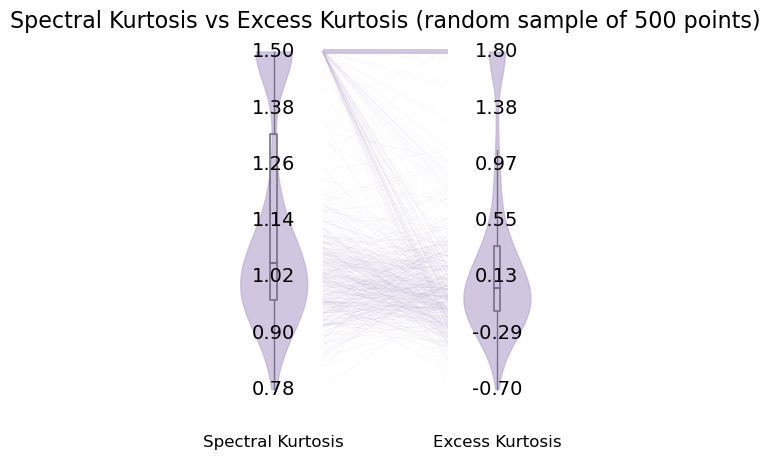

In [153]:
import hammock_plot
freq_indices = np.random.default_rng(1).integers(0, len(sk_vals), size=500)
EK_P_vals = EK_P.flatten()
kurtosis_df = pd.DataFrame({
    "Spectral Kurtosis": np.clip(sk_vals[freq_indices], -0.5, 1.5),
    "Excess Kurtosis": np.clip(EK_P_vals[freq_indices], -0.9, 1.8)
})

hammock = hammock_plot.Hammock(kurtosis_df)
ax = hammock.plot(
    var= ["Spectral Kurtosis", "Excess Kurtosis"],
    uni_vfill=0.7,
    connector_fraction=0.2,
    missing=True,
    display_type={
        "Spectral Kurtosis":"violin", "Excess Kurtosis": "violin"},
    width=6, height=5, alpha=0.7,
)
ax.set_title("Spectral Kurtosis vs Excess Kurtosis (random sample of 500 points)")

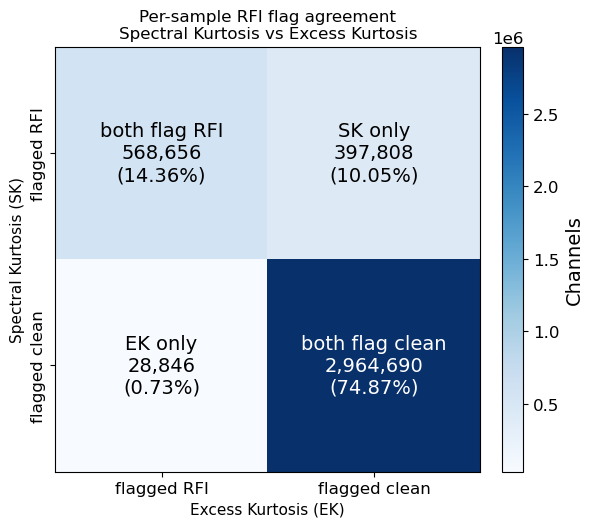

In [130]:
# Build boolean RFI masks from the existing EK and SK thresholds
if "EK_P_vals" not in globals():
    EK_P_vals = EK_P.flatten()

n = min(EK_P_vals.size, sk_vals.size)
ek_rfi = (EK_P_vals[:n] <= p_001) | (EK_P_vals[:n] >= p_999)
sk_rfi = (sk_vals[:n] <= SK_001) | (sk_vals[:n] >= SK_999)

# Confusion matrix: rows = SK (y-axis), cols = EK_P (x-axis)
cm = np.array([
    [np.sum(sk_rfi & ek_rfi),    np.sum(sk_rfi & ~ek_rfi)],     # SK flags RFI
    [np.sum(~sk_rfi & ek_rfi),   np.sum(~sk_rfi & ~ek_rfi)],    # SK flags clean
])

# Plain-English meaning of each quadrant
desc = np.array([
    ["both flag RFI",   "SK only"],
    ["EK only",     "both flag clean"],
])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1], ["flagged RFI", "flagged clean"])
ax.set_yticks([0, 1], ["flagged RFI", "flagged clean"], rotation=90, va="center")
ax.set_xlabel("Excess Kurtosis (EK)", fontsize=11)
ax.set_ylabel("Spectral Kurtosis (SK)", fontsize=11)
ax.set_title("Per-sample RFI flag agreement\nSpectral Kurtosis vs Excess Kurtosis", fontsize=12)

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax.text(
            j, i,
            f"{desc[i, j]}\n{val:,}\n({100*val/n:.2f}%)",
            ha="center", va="center",
            color="white" if val > cm.max() / 2 else "black"
        )

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Channels")
plt.tight_layout()
plt.show()

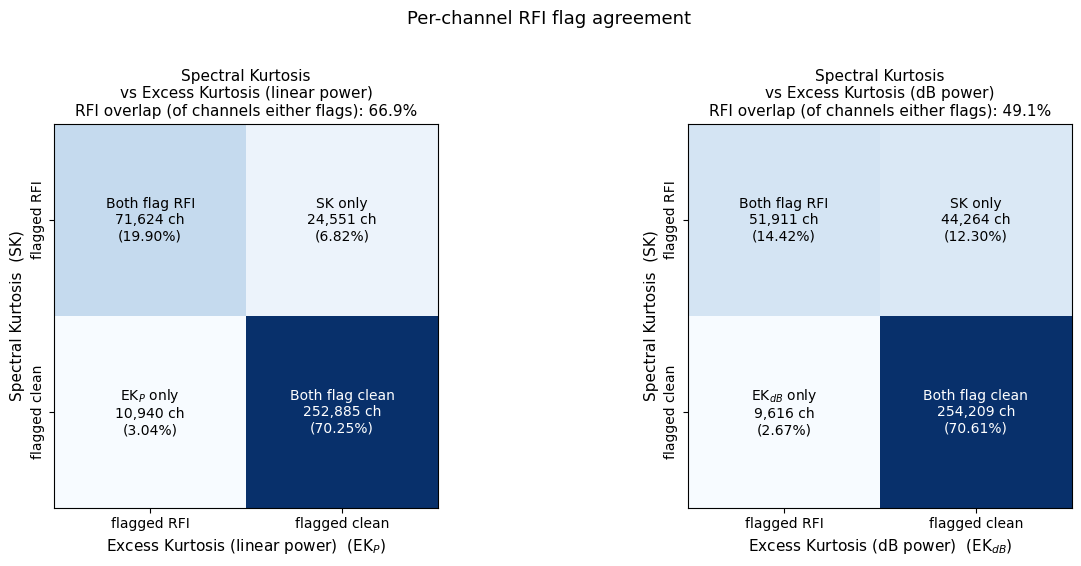

In [42]:
import matplotlib.pyplot as plt

def plot_confusion(a, b, short_a, short_b, full_a, full_b, ax):
    """2x2 agreement matrix between two boolean RFI masks."""
    n  = a.size
    cm = np.array([
        [np.sum(a &  b), np.sum(a & ~b)],     # row 0: method A flags RFI
        [np.sum(~a & b), np.sum(~a & ~b)],    # row 1: method A flags clean
    ])
    desc = np.array([                          # plain-English cell meaning
        ["Both flag RFI",   f"{short_a} only"],
        [f"{short_b} only", "Both flag clean"],
    ])

    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["flagged RFI", "flagged clean"])
    ax.set_yticks([0, 1], ["flagged RFI", "flagged clean"], rotation=90, va="center")
    ax.set_xlabel(f"{full_b}  ({short_b})", fontsize=11)
    ax.set_ylabel(f"{full_a}  ({short_a})", fontsize=11)

    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{desc[i, j]}\n{cm[i, j]:,} ch\n({cm[i, j]/n*100:.2f}%)",
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    both   = cm[0, 0]
    either = cm[0, 0] + cm[0, 1] + cm[1, 0]
    jacc   = 100 * both / either if either else 0.0
    ax.set_title(f"{full_a}\nvs {full_b}\n"
                 f"RFI overlap (of channels either flags): {jacc:.1f}%", fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_confusion(SK_rfi, P_rfi,
               "SK", "EK$_P$", "Spectral Kurtosis", "Excess Kurtosis (linear power)", axes[0])
plot_confusion(SK_rfi, Pdb_rfi,
               "SK", "EK$_{dB}$", "Spectral Kurtosis", "Excess Kurtosis (dB power)", axes[1])
fig.suptitle("Per-channel RFI flag agreement", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [189]:
lines

0      1477.335105
1      1450.716777
2      1424.734102
3      1399.368217
4      1374.600927
          ...     
111     314.489820
112     311.089945
113     307.738901
114     304.435814
115     301.179830
Name: Frequency (MHz), Length: 116, dtype: float64

## plot zoomed in view

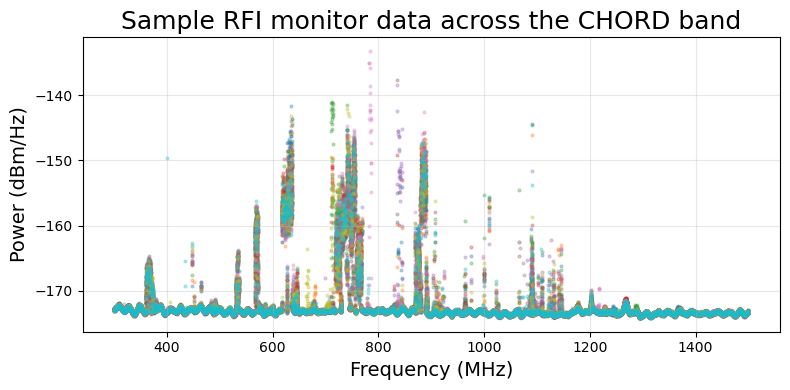

In [187]:
lines = H_lines["Frequency (MHz)"]
def plot_band_traces(
        chord_data, center_freq=750, f_width=10, ylims=None,
        kurtosis=None, kurtosis_type="EK", t_traces=20, f_traces=1000,
        f_max=2000, lines=lines, title=None, ax=None):
    """Scatter-plot a sample of clean time traces over a frequency band.

    f_traces=-1 uses every frequency bin in the band; t_traces=-1 uses
    every clean row. ``kurtosis`` is an optional precomputed array of shape
    (data.shape[1],) (one value per frequency column); when given, a second
    panel beneath the main plot shows the band's kurtosis sharing the same
    frequency x-axis. ``lines`` is an array of frequencies (MHz); any that
    fall inside the band are marked with a dashed vertical line.
    Returns (data_slice, freq_mhz, t_idx).
    """
    # --- frequency columns within the band ---
    f_min, f_max = center_freq - f_width/2, center_freq + f_width/2
    f_i_min = int( (f_min - chord_min) / (chord_max - chord_min) * chord_data.shape[1])
    f_i_max = int( (f_max - chord_min) / (chord_max - chord_min) * chord_data.shape[1])
    
    if f_traces == -1:
        f_idx = np.arange(f_i_min, f_i_max + 1)   # every bin in the band
    else:
        f_idx = np.unique(np.linspace(f_i_min, f_i_max, f_traces, dtype=int))
    f_range = np.linspace(f_min, f_max, f_idx.size)

    # --- sample of clean time rows ---

    if t_traces == -1:
        t_idx = np.arange(chord_data.shape[0])
    else:
        t_idx = np.random.choice(np.arange(chord_data.shape[0]), size=min(t_traces, chord_data.shape[0]), replace=False)  # random sample of rows
    t_idx = np.sort(t_idx)

    # --- the sub-block: every selected row x every selected column ---
    data_slice = chord_data[np.ix_(t_idx, f_idx)]

    # --- axes: add a kurtosis panel underneath when an array is supplied ---
    show_kurtosis = kurtosis is not None
    ax_k = None
    if ax is None:
        if show_kurtosis:
            _, (ax, ax_k) = plt.subplots(
                2, 1, figsize=(8, 5), sharex=True,
                gridspec_kw={"height_ratios": [2, 2]},
            )
        else:
            _, ax = plt.subplots(figsize=(8, 4))

    # --- one scatter series per sampled time trace ---
    for row, t in zip(data_slice, t_idx):
        ax.scatter(f_range, row, s=4, alpha=0.3, label=f"t={t}")

    ax.set_ylabel("Power (dBm/Hz)", fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    else:
        ax.set_title(f"{data_slice.shape[0]} time traces near {center_freq} MHz "
                    f"({center_freq - f_width/2:g}-{center_freq + f_width/2:g} MHz)", fontsize=18)
    if ylims is not None:
        ax.set_ylim(ylims)
    ax.grid(alpha=0.3)

    # --- kurtosis panel (use the precomputed values for this band) ---
    if ax_k is not None:

        if kurtosis_type == "EK":
            ax_k.plot(f_range, np.clip(np.asarray(kurtosis)[f_idx], -0.5, 0.5), color="firebrick", lw=1)
            ax_k.set_ylim(-0.6, 0.6)
            ax_k.axhline(p_001, color="purple", ls="--", lw=1, alpha=0.8)
            ax_k.axhline(p_999, color="purple", ls="--", lw=1, alpha=0.8)
        else:
            ax_k.set_ylim(0, 5)

        ax_k.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.7)  # normal reference
        ax_k.set_ylabel("Excess\nKurtosis", fontsize=14)
        ax_k.set_xlabel("Frequency (MHz)", fontsize=14)
        ax_k.grid(alpha=0.3)
    else:
        ax.set_xlabel("Frequency (MHz)", fontsize=14)

    # --- mark spectral lines that fall inside the band ---
    if lines is not None:
        lines = np.asarray(lines, dtype=float)
        f_lo, f_hi = center_freq - f_width/2, center_freq + f_width/2
        in_band = lines[(lines >= f_lo) & (lines <= f_hi)]
        for axx in (ax, ax_k):
            if axx is None:
                continue
            for L in in_band:
                axx.axvline(L, color="black", ls="--", lw=0.8, alpha=0.6)

    return data_slice, f_range, t_idx


data_slice, freq_mhz, t_idx = plot_band_traces(chord_data, center_freq=900, f_width=1200-1, f_traces=6000, title="Sample RFI monitor data across the CHORD band", lines=None)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/chord_rfi_sample.png", dpi=300)
plt.show()

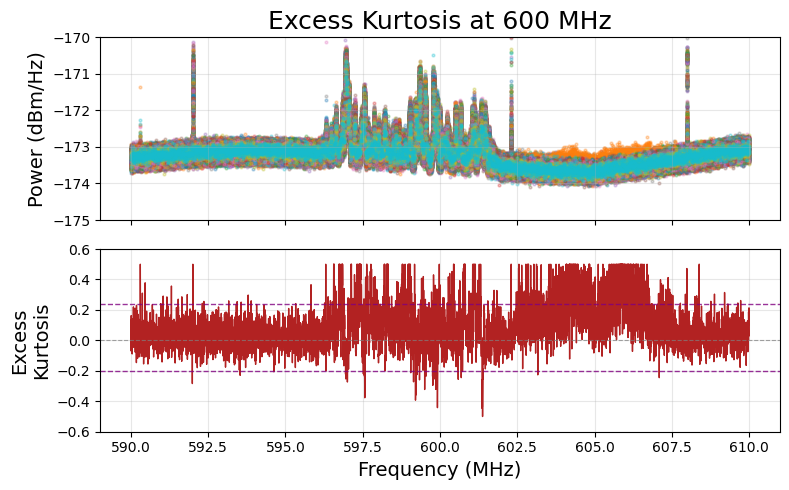

In [189]:
data_slice, freq_mhz, t_idx = plot_band_traces(
    chord_data, center_freq=600, f_width=20, ylims=(-175, -170),
    f_traces=-1, t_traces=1000, 
    title="Excess Kurtosis at 600 MHz", lines=None, kurtosis=g2_P)
plt.tight_layout()
plt.savefig("../../thesis/plots/rfi/600MHz_sample_EK.png", dpi=300)
plt.show()


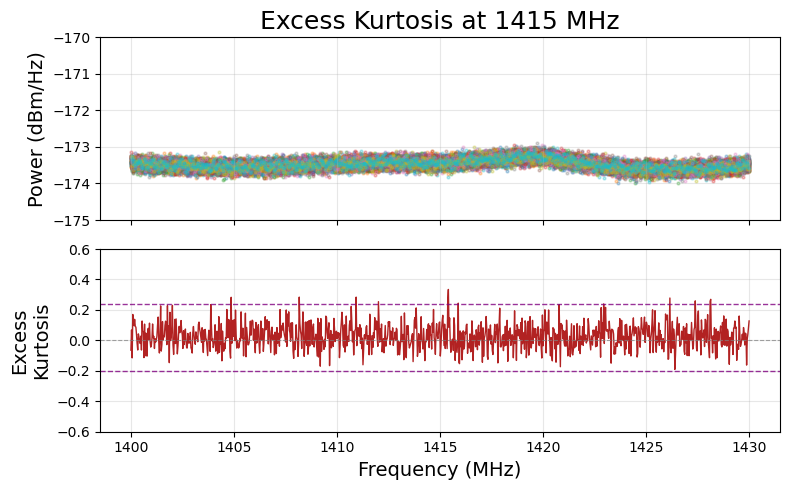

In [335]:
data_slice, freq_mhz, t_idx = plot_band_traces(
    chord_data, center_freq=1415, f_width=30, ylims=(-175, -170),
    f_traces=1000, t_traces=50, 
    title="Excess Kurtosis at 1415 MHz", lines=None, kurtosis=g2_P)
plt.tight_layout()
plt.show()

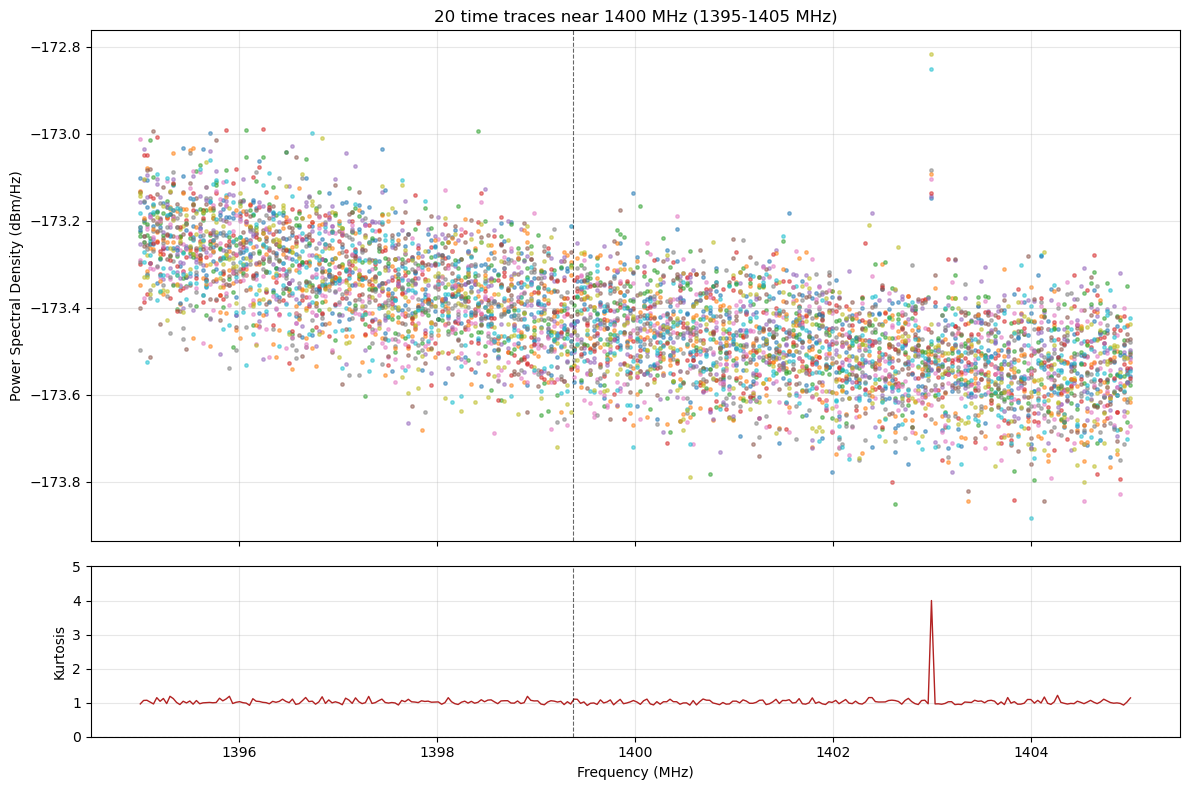

In [31]:
data_slice, freq_mhz, t_idx = plot_band_traces(data, clean_rows, center_freq=1400, f_width=10, f_traces=300, kurtosis=sk_full, kurtosis_type="EK")
plt.tight_layout()
plt.show()

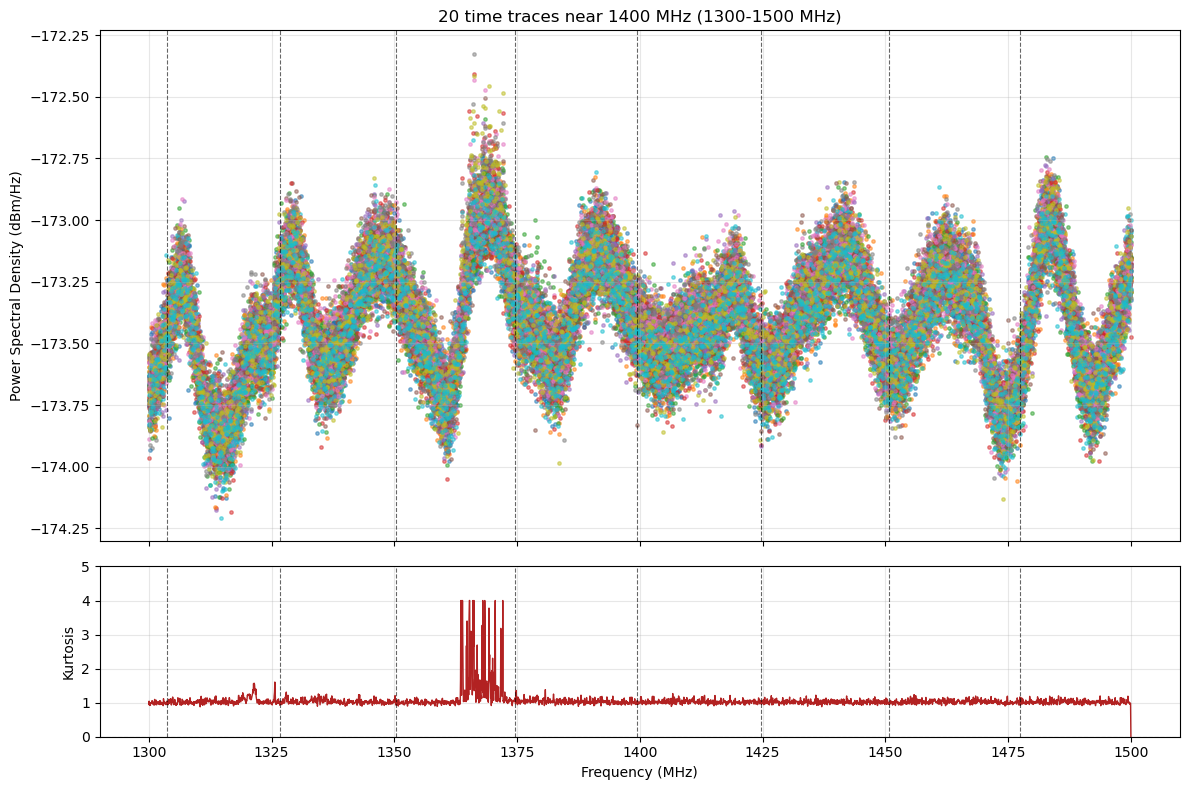

In [ ]:
data_slice, freq_mhz, t_idx = plot_band_traces(data, clean_rows, center_freq=1400, f_width=200, f_traces=3000, kurtosis=sk_full)
plt.tight_layout()
plt.show()

## Look at distribution of raw kurtosis

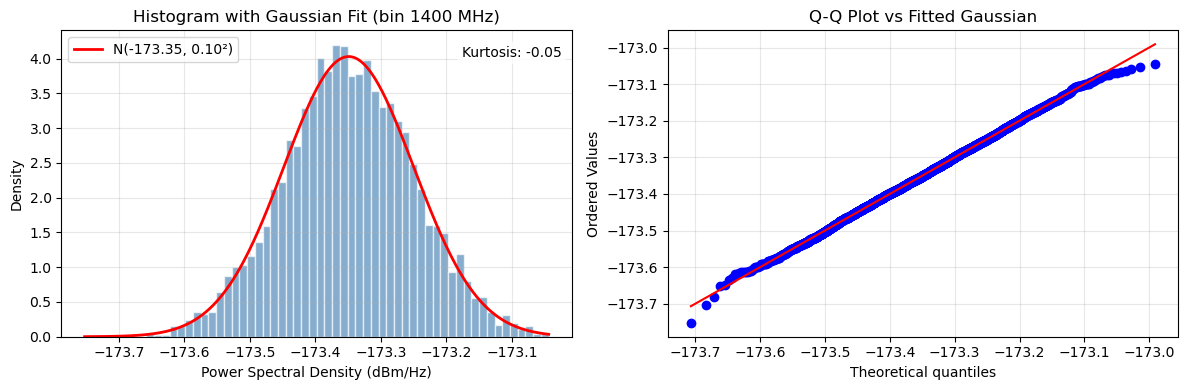

In [ ]:
from scipy import stats

f = 1400 # MHz
f_max = 2000 # MHz
f_index = int(f/f_max * data.shape[1])

x = np.asarray(data[clean_rows, f_index], dtype=np.float64)

mu, sigma = x.mean(), x.std(ddof=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + fitted Gaussian
ax[0].hist(x, bins=60, density=True, alpha=0.65, color="steelblue", edgecolor="white")
xx = np.linspace(x.min(), x.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, loc=mu, scale=sigma), "r-", lw=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
kurt = stats.kurtosis(x, fisher=True, bias=False)
ax[0].text(
    0.98, 0.95,
    f"Kurtosis: {kurt:.2f}",
    transform=ax[0].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
)
ax[0].set_title(f"Histogram with Gaussian Fit (bin {f} MHz)")
ax[0].set_xlabel("Power Spectral Density (dBm/Hz)")
ax[0].set_ylabel("Density")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Q-Q plot against Gaussian fit
stats.probplot(x, dist=stats.norm(loc=mu, scale=sigma), plot=ax[1])
ax[1].set_title("Q-Q Plot vs Fitted Gaussian")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

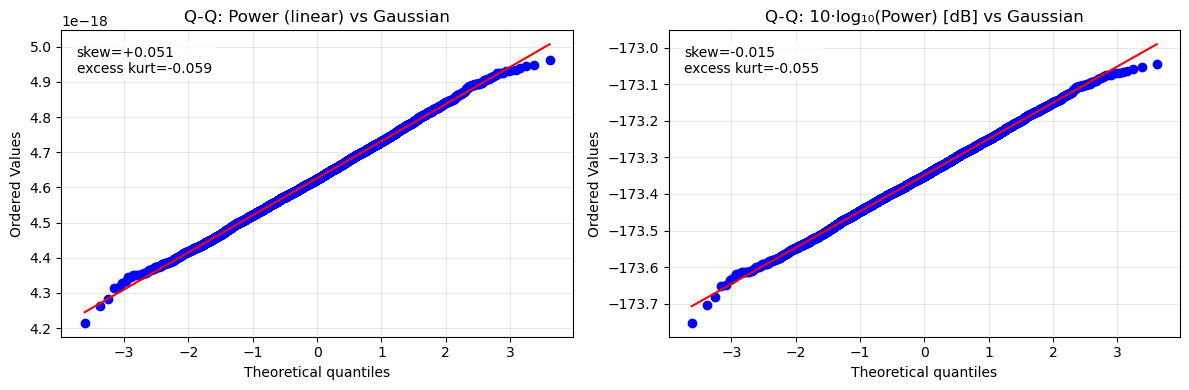

In [ ]:
from scipy import stats

f = 1400; f_max = 2000
f_index = int(f/f_max * data.shape[1])

x_db = np.asarray(data[clean_rows, f_index], dtype=np.float64)

# Invert dB -> linear power (the constant dBm offset is just a scale factor,
# which doesn't affect Gaussianity, so we can ignore it)
power = 10**(x_db / 10)

def annotate(ax, d):
    s = stats.skew(d); k = stats.kurtosis(d, fisher=True, bias=False)
    ax.text(0.03, 0.95, f"skew={s:+.3f}\nexcess kurt={k:+.3f}",
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Is POWER Gaussian?
stats.probplot(power, dist="norm", plot=ax[0])
ax[0].set_title("Q-Q: Power (linear) vs Gaussian"); ax[0].grid(alpha=0.3); annotate(ax[0], power)

# Is 10log10(POWER) Gaussian?
stats.probplot(x_db, dist="norm", plot=ax[1])
ax[1].set_title("Q-Q: 10·log₁₀(Power) [dB] vs Gaussian"); ax[1].grid(alpha=0.3); annotate(ax[1], x_db)

plt.tight_layout(); plt.show()



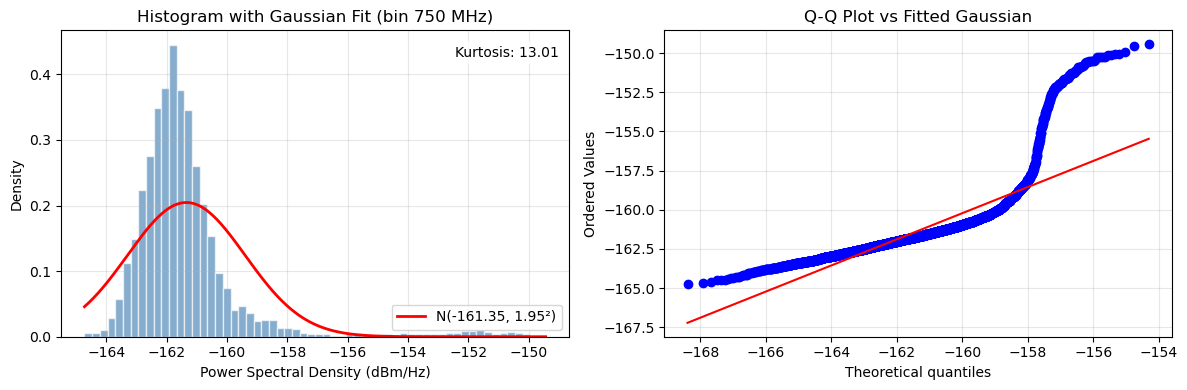

In [ ]:

f = 750 # MHz
f_max = 2000 # MHz
f_index = int(f/f_max * data.shape[1])

x = np.asarray(data[clean_rows, f_index], dtype=np.float64)
mu, sigma = x.mean(), x.std(ddof=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + fitted Gaussian
ax[0].hist(x, bins=60, density=True, alpha=0.65, color="steelblue", edgecolor="white")
xx = np.linspace(x.min(), x.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, loc=mu, scale=sigma), "r-", lw=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
kurt = stats.kurtosis(x, fisher=True, bias=False)
ax[0].text(
    0.98, 0.95,
    f"Kurtosis: {kurt:.2f}",
    transform=ax[0].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
)
ax[0].set_title(f"Histogram with Gaussian Fit (bin {f} MHz)")
ax[0].set_xlabel("Power Spectral Density (dBm/Hz)")
ax[0].set_ylabel("Density")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Q-Q plot against Gaussian fit
stats.probplot(x, dist=stats.norm(loc=mu, scale=sigma), plot=ax[1])
ax[1].set_title("Q-Q Plot vs Fitted Gaussian")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Explore Kurtosis to select a cutoff value

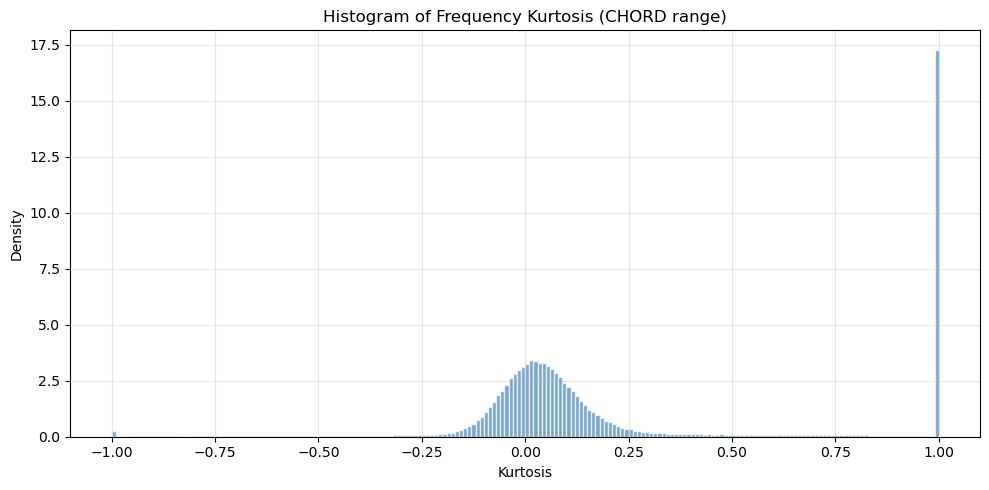

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(np.clip(freq_kurtosis[chord_range], -1, 1), bins=200, density=True, alpha=0.7, color="steelblue", edgecolor="white")
plt.xlabel("Kurtosis")
plt.ylabel("Density")
plt.title("Histogram of Frequency Kurtosis (CHORD range)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
i0, i1 = int(chord_min/f_max*data.shape[1]), int(chord_max/f_max*data.shape[1])
ncol = i1 - i0

valid_idx = np.flatnonzero(clean_rows)   # integer row indices to keep
M = valid_idx.size                       # total rows (was P.shape[0])

s1 = np.zeros(ncol, dtype=np.float64)    # Σ P   over rows
s2 = np.zeros(ncol, dtype=np.float64)    # Σ P²  over rows

block = 200                              # rows per block — tune to your RAM
for start in range(0, M, block):
    rows = valid_idx[start:start + block]
    P = 10.0 ** (np.asarray(data[rows, i0:i1], dtype=np.float64) / 10.0)
    s1 += P.sum(axis=0)
    s2 += np.square(P).sum(axis=0)

N, d = 2500, 0.5                          # N = Δf·τ from SigMF metadata; CHECK it
sk = ((M*N*d + 1.0)/(M - 1.0)) * (M*s2/s1**2 - 1.0)   # null = 1

sk_full = np.zeros(data.shape[1], dtype=np.float64)
sk_full[i0:i1] = sk


array([1.45036197, 1.52126753, 1.81789928, ..., 1.17743039, 1.19006585,
       1.32723959], shape=(360000,))

In [ ]:
N, d = 2000, 1                         # N = Δf·τ from SigMF metadata; CHECK it
sk = ((M*N*d + 1.0)/(M - 1.0)) * (M*s2/s1**2 - 1.0)   # null = 1

sk_full = np.zeros(data.shape[1], dtype=np.float64)
sk_full[i0:i1] = sk

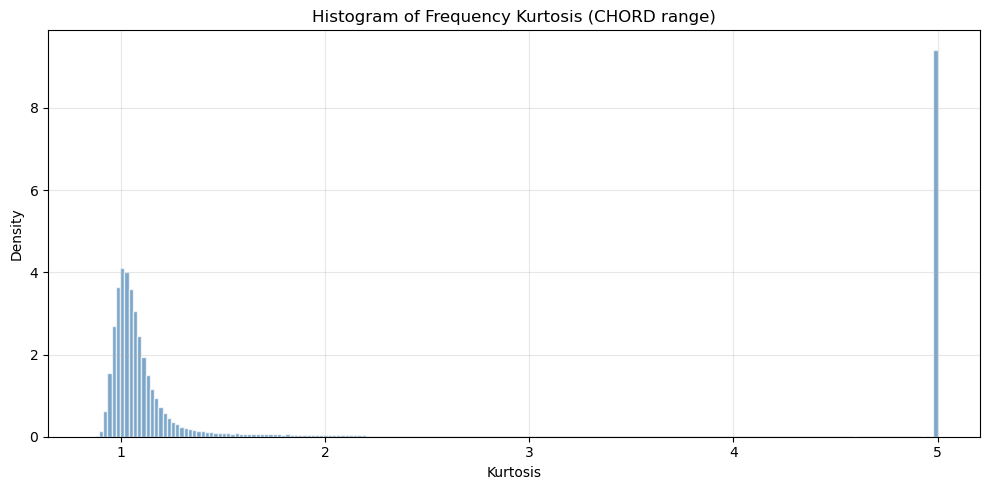

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(np.clip(sk, -5, 5), bins=200, density=True, alpha=0.7, color="steelblue", edgecolor="white")
plt.xlabel("Kurtosis")
plt.ylabel("Density")
plt.title("Histogram of Frequency Kurtosis (CHORD range)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
kurtosis_sample = kurtosis_df.sample(n=1000, random_state=42)
kurtosis_sample

,spectral_kurtosis,raw_kurtosis
76637,1.233705,0.212056
64372,1.372702,-0.042332
252387,1.342101,3.113831
251573,5.000000,5.000000
318742,1.242071,0.063362
...,...,...
341838,1.276642,0.039573
32617,1.352725,-0.006269
331898,1.272060,-0.027234
77410,1.357448,0.415486


In [ ]:
kurtosis_df.sample(n=1000, random_state=1).spectral_kurtosis.min()

np.float64(1.13025311971908)

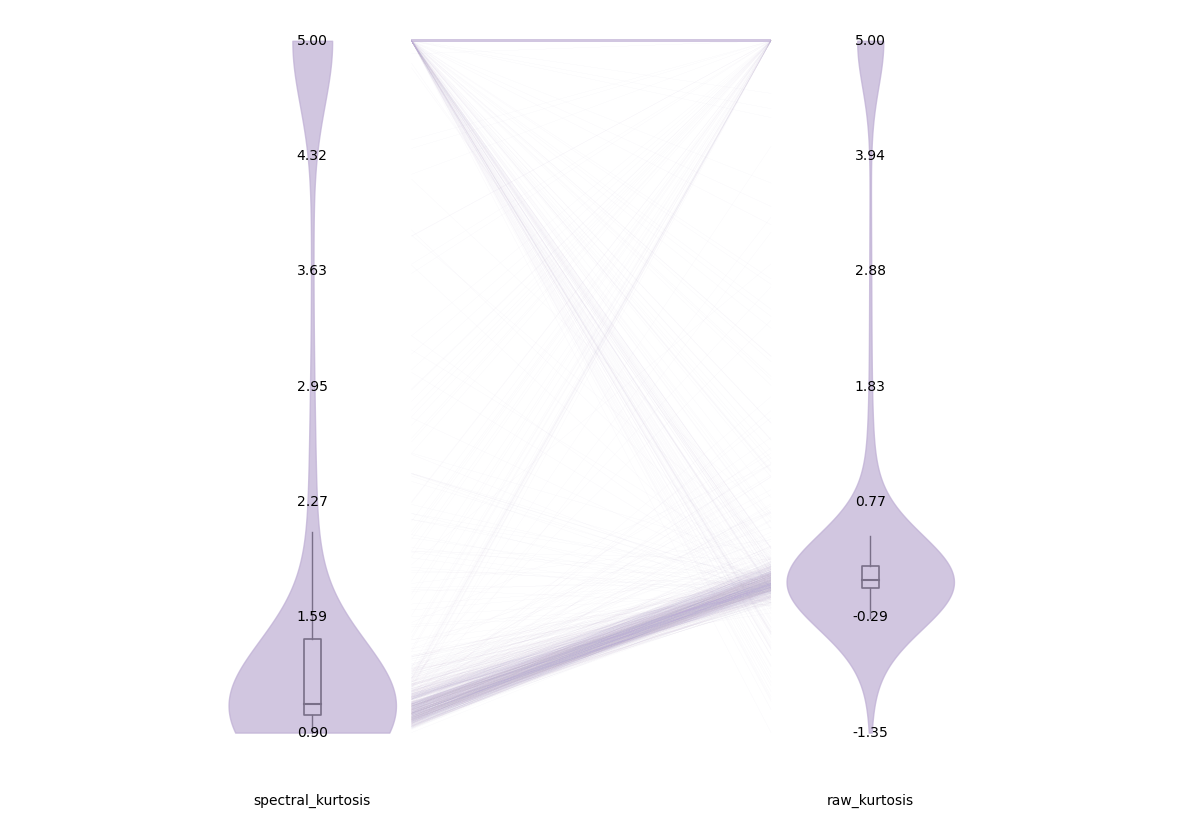

In [ ]:
import hammock_plot

kurtosis_df = pd.DataFrame({
    "spectral_kurtosis": np.clip(sk, -5, 5),
    "raw_kurtosis": np.clip(freq_kurtosis[chord_range], -5, 5),
})

hammock = hammock_plot.Hammock(kurtosis_df.sample(n=1000, random_state=1))
ax = hammock.plot(
    var= ["spectral_kurtosis", "raw_kurtosis"],
    uni_vfill=0.7,
    connector_fraction=0.1,
    missing=True,
    display_type={"spectral_kurtosis":"violin", "raw_kurtosis": "violin"},
)